# Tutorial05 · Spam Message Classification

Understand real SMS data, train and validate models, then test the final choice

**Tutor:** Yinghao Zhu · yhzhu99@connect.hku.hk

Given the text of an English SMS, predict ham (a normal message, label 0) or spam (an unsolicited promotional message, label 1). We learn from the original UCI SMS Spam Collection: 5,574 labelled messages, one label and one message per row.

Start by downloading and opening the dataset. Inspect real messages, repeated records and class imbalance before deciding how to represent text. Follow every chapter in order: reserve train, validation and test sets, fit each model on training data, select its settings on validation data, compare errors and evaluate the frozen final choice once. The numerical chapters cover LDA and a binomial additive spline model (GAM).

## Open the SMS Spam Collection

Source: [UCI SMS Spam Collection](https://archive.ics.uci.edu/dataset/228/sms+spam+collection) · [Download original ZIP](https://archive.ics.uci.edu/static/public/228/sms+spam+collection.zip) · Local file: `data/SMSSpamCollection.txt`

Download the original UCI ZIP and extract SMSSpamCollection, or download the identical bundled text file below. Open it in a text editor: there is no header, each line is label<TAB>message, and the first tab separates the two fields. Preserve the original spelling, punctuation and spacing.

Raw data: 5,574 SMS; 4,827 ham and 747 spam. No header.

```text
ham	Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...
ham	Ok lar... Joking wif u oni...
spam	Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's
ham	U dun say so early hor... U c already then say...
ham	Nah I don't think he goes to usf, he lives around here though
```

This is a historical English SMS research corpus compiled from several sources, including Singaporean student messages and UK spam complaints. It contains abbreviations, phone numbers, links, currency and repeats. It has no email subject, sender metadata or attachments. Its results do not establish performance on modern email, Chinese text or another population.

## Learning route

1. **SMS Data and Train / Validation / Test** — Inspect the data and reserve messages for fair evaluation.
2. **Text Classification: Spam or Ham** — Turn a new message into a spam / ham prediction.
3. **Tokenization: From Text to Tokens** — See how a string becomes a sequence of tokens.
4. **Bag of Words: From Tokens to Counts** — Build a vocabulary, then count the words in each message.
5. **TF–IDF: Weighting Words by Rarity** — Weight words using both their counts and their frequency across documents.
6. **Naive Bayes: Classifying by Word Evidence** — Learn which words occur in each class, then classify a new message.
7. **Logistic Regression: Learning Word Weights** — Reuse a familiar classifier with word vectors as inputs.
8. **KNN: Voting from Similar Messages** — Inspect the messages that vote on a new prediction.
9. **Regularization: Controlling Word Weights** — Should one rare word receive a huge weight?
10. **Cross-Validation: Choosing C without Leakage** — What must be fitted again inside each fold?
11. **Numerical Features: Measuring a Message** — What can we measure before understanding language?
12. **LDA: Modelling Each Class Distribution** — What changes if we model the features within each class?
13. **GAM: Learning Curved Feature Effects** — Allow curved effects of the log-transformed numerical measurements.
14. **Evaluation: Compare Models and Inspect Errors** — Compare choices fairly, inspect mistakes, then evaluate the selected model.

Follow every chapter in order. Each model has training, validation selection and a shared final test stage. Each chapter explains its inputs and uses the setup below.

## Learning objectives

- Download and read the original SMS file, explain its labels, imbalance and limitations.
- Remove duplicates before a stratified train / validation / test split and explain the purpose of each set.
- Trace real SMS messages through NLTK tokens, word counts and training-fitted TF–IDF.
- Use formulas, fitted parameters and worked calculations to explain NB, LR and KNN predictions.
- Choose distance metrics and hyperparameters using validation evidence, with every fitted step inside a pipeline.
- Compare all studied models, inspect errors, freeze a model and threshold, and report one final test.

**Prerequisites:** Basic Python and familiarity with classification from lectures. No previous NLP course is needed. The later chapters reconnect to regularization, cross-validation, LDA and GAM.

**Outcome:** An executed notebook covering every chapter: a dataset audit, real-message feature calculations, training and validation comparisons for all models, error analysis and a justified final test result.

## Setup

Extract the complete student package and keep all supporting files beside the notebook, including `experiment.py`, `model_figures.py`, `model_examples.json` and `data/`. Install `requirements.txt`. NLTK’s Treebank tokenizer needs no resource downloads.

Setup supplies training and validation arrays. Test messages remain reserved for the final cell. Data provenance is in `data/README.md`; the next section shows the data split. The examples import NLTK and sklearn tools explicitly.

In [1]:
import json
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from experiment import Experiment, tokens, numerical_features, metrics, explain_model
from diagrams import draw_flow
from model_figures import nb_example, lr_example, knn_example, plot_evidence, plot_neighbors, lr_flow_values, knn_flow_values, prediction_flow

dataset_path = "data/SMSSpamCollection.txt"
lab = Experiment(dataset_path)
X_train, y_train = lab.X_train.copy(), lab.y_train.copy()
X_val, y_val = lab.X_val.copy(), lab.y_val.copy()
initial = lab.initialize()
curriculum = json.loads(Path("curriculum.json").read_text())
model_examples = json.loads(Path("model_examples.json").read_text())
plt.rcParams.update({"figure.figsize": (9, 4), "axes.spines.top": False, "axes.spines.right": False})
HAM, SPAM = "#45657e", "#aa613d"

## 1. SMS Data and Train / Validation / Test

### From raw SMS to a fair data split

First open the dataset: each row is one real SMS and its known ham/spam label. Our task is to learn from labelled training messages and predict labels for unseen messages.

- The raw file has 5,574 rows: 4,827 ham (86.6%) and 747 spam (13.4%). These are class counts before deduplication.
- Matching text after lowercasing and collapsing whitespace removes 415 repeats, leaving 5,159 distinct messages: 4,517 ham and 642 spam. The retained message text is unchanged.
- Deduplicate before splitting, so repeated messages cannot appear in both training and evaluation. Use a stratified 60% / 20% / 20% split with seed 3612.
- Train: 3,095 messages (2,710 ham, 385 spam). Validation: 1,032 (903 ham, 129 spam). Test: 1,032 (904 ham, 128 spam). Fit all learned transformations on training data only.

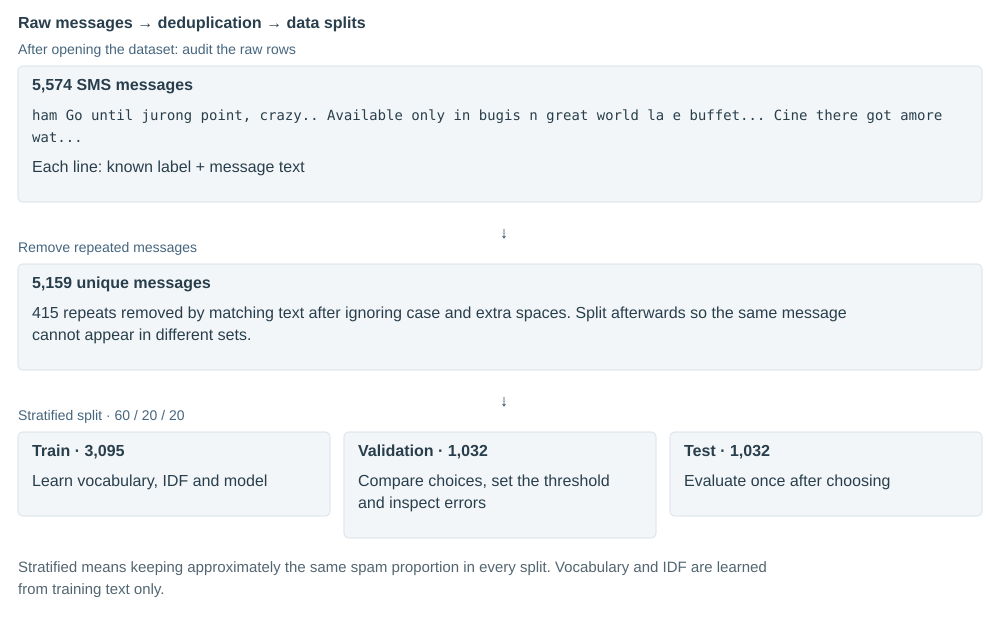

In [2]:
draw_flow(curriculum["chapters"][0]["flow"], initial)

### Inspect messages and class imbalance

Find one ham and one spam message in the table. Identify useful words and explain why accuracy alone may mislead.

### Python: labels and the always-ham baseline

Run the example, change one input or choice, then explain the output.

In [3]:
import csv
from pathlib import Path
from sklearn.model_selection import train_test_split

# 1. Open the downloaded file before processing anything.
path = Path(dataset_path)
with path.open(encoding="utf-8-sig", newline="") as handle:
    rows = list(csv.reader(handle, delimiter="\t", quoting=csv.QUOTE_NONE))
print("Raw rows:", len(rows))
for label, message in rows[:5]:
    print(label, "|", message)
print("Raw ham / spam:", sum(r[0] == "ham" for r in rows), sum(r[0] == "spam" for r in rows))

# 2. Deduplicate identities while preserving the original text.
unique = {}
for label, message in rows:
    identity = " ".join(message.lower().split())
    unique.setdefault(identity, (message, int(label == "spam")))
texts = np.array([r[0] for r in unique.values()])
labels = np.array([r[1] for r in unique.values()])
print("Distinct messages:", len(texts), "Repeats removed:", len(rows) - len(texts))

# 3. Reserve 20% test; 25% of the remaining 80% gives 20% validation.
train_val, test_ids = train_test_split(np.arange(len(labels)), test_size=.2, stratify=labels, random_state=3612)
train_ids, val_ids = train_test_split(train_val, test_size=.25, stratify=labels[train_val], random_state=3612)
for name, ids in [("train", train_ids), ("validation", val_ids), ("test", test_ids)]:
    print(name, len(ids), "ham:", sum(labels[ids] == 0), "spam:", sum(labels[ids] == 1))
# Inspect train/validation only; reserve test text and labels for the final evaluation.
baseline = metrics(y_val, np.zeros(len(y_val)))
print("Always-ham accuracy:", round(baseline["accuracy"], 3))
print("Always-ham recall:", baseline["recall"])

Raw rows: 5574
ham | Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...
ham | Ok lar... Joking wif u oni...
spam | Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's
ham | U dun say so early hor... U c already then say...
ham | Nah I don't think he goes to usf, he lives around here though
Raw ham / spam: 4827 747
Distinct messages: 5159 Repeats removed: 415
train 3095 ham: 2710 spam: 385
validation 1032 ham: 903 spam: 129
test 1032 ham: 904 spam: 128
Always-ham accuracy: 0.875
Always-ham recall: 0.0


## 2. Text Classification: Spam or Ham

### Messages, labels and predictions

Text classification assigns a category to a piece of text.

- Our input is a message; its label is ham (normal, 0) or spam (1). Training examples contain both text and a known label.
- Natural language processing (NLP) includes tasks that work with human language. Spam filtering and sentiment classification are two examples.

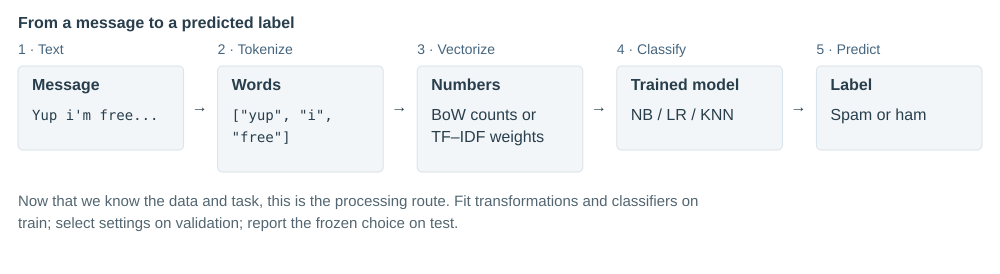

In [4]:
draw_flow(curriculum["chapters"][1]["flow"], initial)

### One keyword is not enough

Both messages contain `free`, but they need different labels. We want to learn from many words together.

| Message | Label |
| --- | --- |
| `500 free text msgs. Just text ok to 80488 and we'll credit your account` | Spam (actual training SMS) |
| `Yup i'm free...` | Ham (actual training SMS) |

### Test a keyword rule

Add one normal message that contains `free`. Explain why this rule cannot distinguish the messages.

### Python: a keyword rule and its mistakes

Run the example, change one input or choice, then explain the output.

In [5]:
messages = ["500 free text msgs. Just text ok to 80488 and we'll credit your account", "Yup i'm free..."]
for message in messages:
    print("Keyword prediction:", "spam" if "free" in message.lower() else "ham", "|", message)

Keyword prediction: spam | 500 free text msgs. Just text ok to 80488 and we'll credit your account
Keyword prediction: spam | Yup i'm free...


## 3. Tokenization: From Text to Tokens

### Lowercase, tokenize, filter

Tokenization splits text into units that we can count.

- `TreebankWordTokenizer` from NLTK splits English words and punctuation; it needs no language-resource downloads.
- Use the same preprocessing for training and new messages. English tokenization does not solve Chinese word segmentation.

### NLTK: tokenize, then keep alphanumeric tokens

```python
from nltk.tokenize import TreebankWordTokenizer
text = "Win a £1000 cash prize or a prize worth £5000"
raw = TreebankWordTokenizer().tokenize(text.lower())
kept = [word for word in raw if word.isalnum()]
print("NLTK tokens:", raw)
print("Retained tokens:", kept)
```

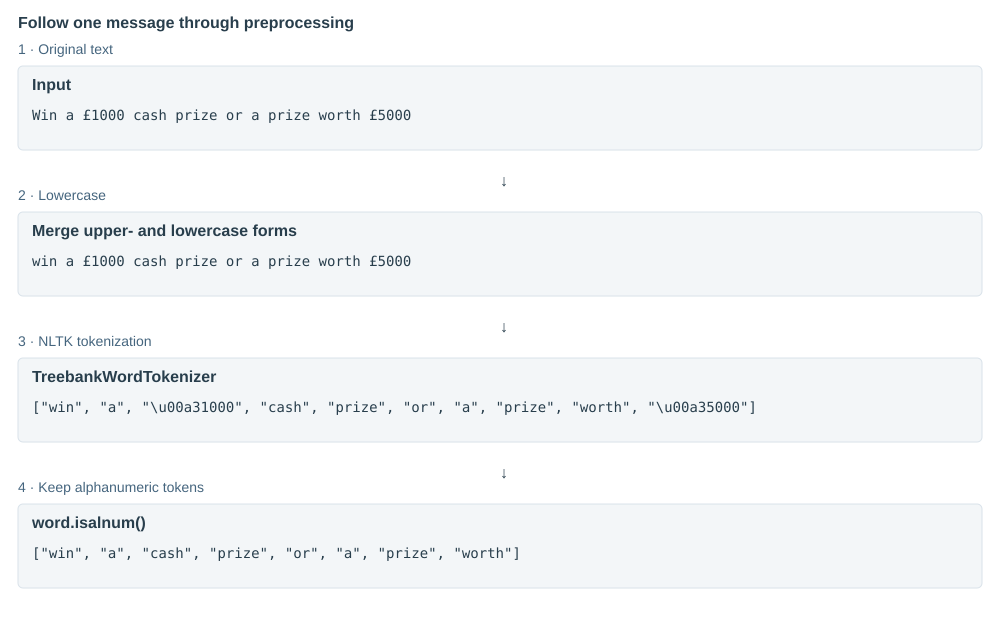

In [6]:
draw_flow(curriculum["chapters"][2]["flow"], initial)

### What preprocessing keeps and loses

Lowercasing merges `FREE` and `free`. Keeping only `.isalnum()` tokens discards punctuation such as `!!!`; currency, URLs and contractions can also lose useful evidence.

Compare stemming with unchanged tokens below. This baseline keeps the unchanged tokens; changing preprocessing requires a new validation comparison. Removing `not` can change meaning.

[NLTK tokenizers](https://www.nltk.org/api/nltk.tokenize.html)

### Trace your own message

Try “I am not winning £1000!!!”. Inspect what is retained, discarded and stemmed. Which changes might remove useful evidence?

### Python: NLTK tokenization and stemming

Run the example, change one input or choice, then explain the output.

In [7]:
from nltk.tokenize import TreebankWordTokenizer
from nltk.stem import PorterStemmer

text = "Win a £1000 cash prize or a prize worth £5000"
raw = TreebankWordTokenizer().tokenize(text.lower())
kept = [word for word in raw if word.isalnum()]
print("NLTK tokens:", raw)
print("Retained tokens:", kept)
stemmer = PorterStemmer()
print("Stemming comparison:", [(word, stemmer.stem(word)) for word in kept])

NLTK tokens: ['win', 'a', '£1000', 'cash', 'prize', 'or', 'a', 'prize', 'worth', '£5000']
Retained tokens: ['win', 'a', 'cash', 'prize', 'or', 'a', 'prize', 'worth']
Stemming comparison: [('win', 'win'), ('a', 'a'), ('cash', 'cash'), ('prize', 'prize'), ('or', 'or'), ('a', 'a'), ('prize', 'prize'), ('worth', 'worth')]


## 4. Bag of Words: From Tokens to Counts

### Build a vocabulary, then count words

Bag of Words represents a message as a vector of word counts.

- There are multiple ways to extract features from text. We start with Bag of Words (BoW), implemented by sklearn’s `CountVectorizer`.
- Create a vocabulary from the training documents. Then count each vocabulary word in each document: one message per row, one word per column.
- The “bag” ignores grammar and word order. Reordering words leaves the count vector unchanged.

### Two real SMS messages, one shared vocabulary

Training SMS A: `Yup i'm free...` Training SMS B: `Now am free call me pa.`

The columns below are learned from these two training rows. The full model later learns from all 3,095 training messages.

| Message | `am` | `call` | `free` | `i` | `me` | `now` | `pa` | `yup` |
| --- | --- | --- | --- | --- | --- | --- | --- | --- |
| SMS A | 0 | 0 | 1 | 1 | 0 | 0 | 0 | 1 |
| SMS B | 1 | 1 | 1 | 0 | 1 | 1 | 1 | 0 |

### Read the matrix

`free` appears once in each row. Every row uses the same columns, even when its word count is zero.

`fit_transform()` learns the training vocabulary and counts words. `transform()` reuses those columns for new messages; unknown words are ignored.

Read `get_feature_names_out()` alongside the matrix. Real matrices stay sparse because most entries are zero.

[CountVectorizer documentation](https://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.CountVectorizer.html)

### Build and inspect a count matrix

Repeat a word, reorder a sentence, then add an unseen word. Predict which columns change before running the code.

### Python: CountVectorizer and unseen words

Run the example, change one input or choice, then explain the output.

In [8]:
from sklearn.feature_extraction.text import CountVectorizer
from experiment import tokens

messages = ["Yup i'm free...", 'Now am free call me pa.']
vectorizer = CountVectorizer(tokenizer=tokens, token_pattern=None, lowercase=False)
X = vectorizer.fit_transform(messages)
print("Vocabulary:", vectorizer.get_feature_names_out())
print("Count matrix:\n", X.toarray())
print("New message:", vectorizer.transform(["Once free call me sir."]).toarray())

# Does word order change a bag-of-words vector?
for message in ["free call", "call free", "free unknownword"]:
    print(message, "→", vectorizer.transform([message]).toarray())

# Apply the same procedure to the full dataset, with no validation fitting.
full_vectorizer = CountVectorizer(tokenizer=tokens, token_pattern=None, lowercase=False, min_df=2, max_features=2500)
train_matrix = full_vectorizer.fit_transform(X_train)
val_matrix = full_vectorizer.transform(X_val)
print("Full training / validation shapes:", train_matrix.shape, val_matrix.shape)
print("Real validation SMS:", X_val[273])
print("Known words:", [(full_vectorizer.get_feature_names_out()[j], round(value, 3)) for j, value in zip(val_matrix[273].indices, val_matrix[273].data)])

Vocabulary: ['am' 'call' 'free' 'i' 'me' 'now' 'pa' 'yup']
Count matrix:
 [[0 0 1 1 0 0 0 1]
 [1 1 1 0 1 1 1 0]]
New message: [[0 1 1 0 1 0 0 0]]
free call → [[0 1 1 0 0 0 0 0]]
call free → [[0 1 1 0 0 0 0 0]]
free unknownword → [[0 0 1 0 0 0 0 0]]


Full training / validation shapes: (3095, 2459) (1032, 2459)
Real validation SMS: Finished class where are you.
Known words: [('are', np.int64(1)), ('class', np.int64(1)), ('finished', np.int64(1)), ('where', np.int64(1)), ('you', np.int64(1))]


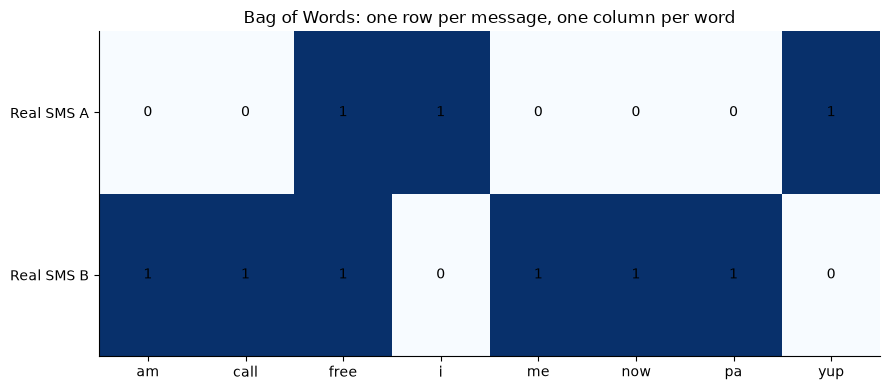

In [9]:
fig, ax = plt.subplots()
matrix = X.toarray()
ax.imshow(matrix, cmap="Blues", aspect="auto")
ax.set_xticks(range(matrix.shape[1]), vectorizer.get_feature_names_out())
ax.set_yticks([0, 1], ["Real SMS A", "Real SMS B"])
for (row, col), value in np.ndenumerate(matrix):
    ax.text(col, row, str(value), ha="center", va="center", color="white" if value == 2 else "black")
ax.set_title("Bag of Words: one row per message, one column per word")
plt.tight_layout()
plt.show()

## 5. TF–IDF: Weighting Words by Rarity

### Why common words get less weight

TF–IDF reduces the weight of words that occur in many documents.

- TF (term frequency) is the word count in the current document here. DF (document frequency) counts documents containing the word, once per document.
- IDF (inverse document frequency) is larger for words that appear in fewer training documents. Multiply TF by IDF to obtain a weight.
- TF–IDF uses no class labels. A rare word is not automatically evidence of spam. The classifier learns how features relate to labels.

### Formula and notation

$$\mathrm{idf}_j=\log\frac{1+n}{1+\mathrm{df}_j}+1,\quad v_j=\mathrm{TF}_j\,\mathrm{idf}_j,\quad x_j=\frac{v_j}{\sqrt{\sum_k v_k^2}}$$

- $n$: number of training documents
- $\mathrm{df}_j$: training documents containing word j
- $v_j$: weight before normalization
- $x_j$: normalized feature; a zero row stays zero

### Document frequency in three real training SMS

SMS 1: `Yup i'm free...`

SMS 2: `Now am free call me pa.`

SMS 3: `500 free text msgs. Just text ok to 80488 and we'll credit your account`

Read the column for `free`: it occurs in all three SMS. `account` occurs only in SMS 3. TF is a token count within one message; DF is a count of training messages.

| Word | TF in SMS 3 | DF | Smoothed IDF | TF × IDF in SMS 3 |
| --- | --- | --- | --- | --- |
| `free` | 1 | 3 | 1.000 | 1.000 |
| `account` | 1 | 1 | 1.693 | 1.693 |

### Smoothed IDF and row normalization

sklearn uses natural log: IDF = log((1 + n) / (1 + DF)) + 1. Smoothing avoids a zero denominator; the final +1 gives words present in every document IDF = 1.

The flow follows SMS 1. The default norm="l2" divides its weights by the row length. Use norm=None to inspect weights before normalization.

Repeating a whole message changes the counts but leaves its normalized vector unchanged. An all-unknown message remains a zero vector.

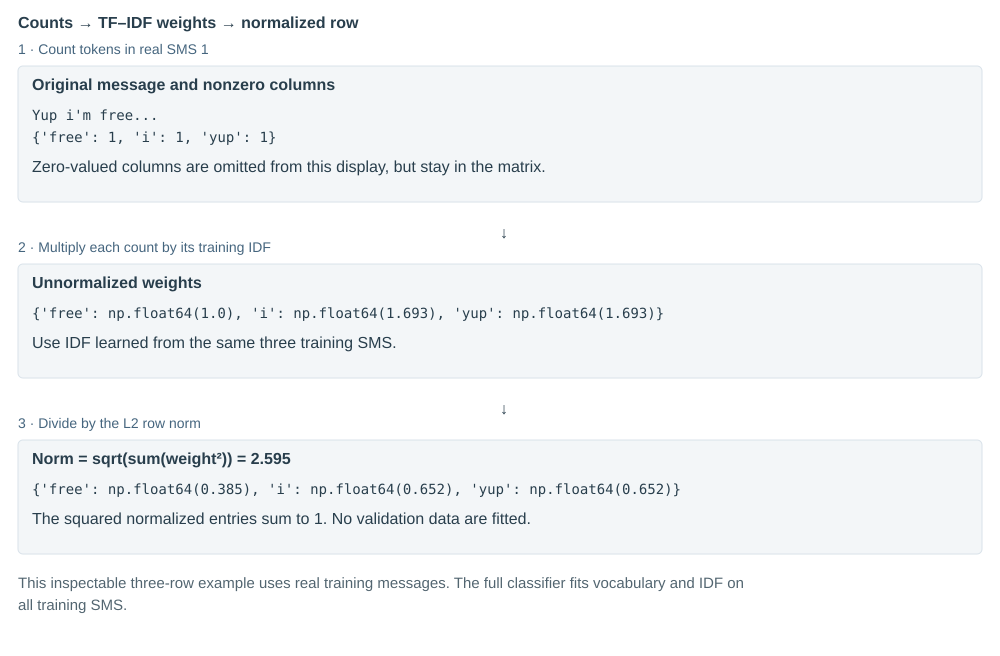

In [10]:
draw_flow(curriculum["chapters"][4]["flow"], initial)

[TfidfVectorizer documentation](https://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.TfidfVectorizer.html)

### Change document frequency and inspect the weights

Add `account` to another training SMS. Predict its IDF change, check the weights and normalization, then reuse the full training-fitted vocabulary on validation.

### Python: IDF, weights and normalization

Run the example, change one input or choice, then explain the output.

In [11]:
from sklearn.feature_extraction.text import TfidfVectorizer
from experiment import tokens

documents = ["Yup i'm free...", 'Now am free call me pa.', "500 free text msgs. Just text ok to 80488 and we'll credit your account"]
raw = TfidfVectorizer(tokenizer=tokens, token_pattern=None, lowercase=False, norm=None)
weighted = raw.fit_transform(documents).toarray()
print("Vocabulary:", raw.get_feature_names_out())
print("IDF:", np.round(raw.idf_, 3))
print("TF × IDF:\n", np.round(weighted, 3))
norms = np.linalg.norm(weighted, axis=1, keepdims=True)
normalized = np.divide(weighted, norms, out=np.zeros_like(weighted), where=norms != 0)
default = TfidfVectorizer(tokenizer=tokens, token_pattern=None, lowercase=False)
print("Normalized TF–IDF:\n", np.round(default.fit_transform(documents).toarray(), 3))
print("Manual normalization matches sklearn:", np.allclose(normalized, default.transform(documents).toarray()))

# Make account less rare: predict the IDF change before running.
for documents in [documents, documents + ["free text account"]]:
    vectorizer = TfidfVectorizer(tokenizer=tokens, token_pattern=None, lowercase=False)
    vectorizer.fit(documents)
    print("Changed IDF:", dict(zip(vectorizer.get_feature_names_out(), np.round(vectorizer.idf_, 3))))
print("Repeated document:")
print(np.round(vectorizer.transform(["claim your prize", "claim your prize claim your prize"]).toarray(), 3))

# Apply the same procedure to the full dataset, with no validation fitting.
full_vectorizer = TfidfVectorizer(tokenizer=tokens, token_pattern=None, lowercase=False, min_df=2, max_features=2500)
train_matrix = full_vectorizer.fit_transform(X_train)
val_matrix = full_vectorizer.transform(X_val)
print("Full training / validation shapes:", train_matrix.shape, val_matrix.shape)
print("Real validation SMS:", X_val[273])
print("Known words:", [(full_vectorizer.get_feature_names_out()[j], round(value, 3)) for j, value in zip(val_matrix[273].indices, val_matrix[273].data)])

Vocabulary: ['500' '80488' 'account' 'am' 'and' 'call' 'credit' 'free' 'i' 'just' 'me'
 'now' 'ok' 'pa' 'text' 'to' 'we' 'your' 'yup']
IDF: [1.693 1.693 1.693 1.693 1.693 1.693 1.693 1.    1.693 1.693 1.693 1.693
 1.693 1.693 1.693 1.693 1.693 1.693 1.693]
TF × IDF:
 [[0.    0.    0.    0.    0.    0.    0.    1.    1.693 0.    0.    0.
  0.    0.    0.    0.    0.    0.    1.693]
 [0.    0.    0.    1.693 0.    1.693 0.    1.    0.    0.    1.693 1.693
  0.    1.693 0.    0.    0.    0.    0.   ]
 [1.693 1.693 1.693 0.    1.693 0.    1.693 1.    0.    1.693 0.    0.
  1.693 0.    3.386 1.693 1.693 1.693 0.   ]]
Normalized TF–IDF:
 [[0.    0.    0.    0.    0.    0.    0.    0.385 0.652 0.    0.    0.
  0.    0.    0.    0.    0.    0.    0.652]
 [0.    0.    0.    0.432 0.    0.432 0.    0.255 0.    0.    0.432 0.432
  0.    0.432 0.    0.    0.    0.    0.   ]
 [0.264 0.264 0.264 0.    0.264 0.    0.264 0.156 0.    0.264 0.    0.
  0.264 0.    0.528 0.264 0.264 0.264 0.   ]]
Manual n

Full training / validation shapes: (3095, 2459) (1032, 2459)
Real validation SMS: Finished class where are you.
Known words: [('are', np.float64(0.328)), ('class', np.float64(0.537)), ('finished', np.float64(0.604)), ('where', np.float64(0.443)), ('you', np.float64(0.206))]


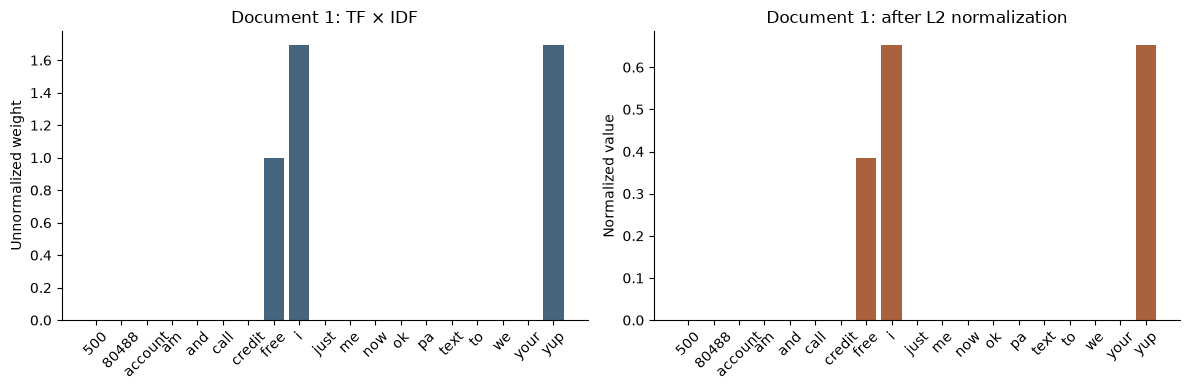

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
names = raw.get_feature_names_out()
axes[0].bar(names, weighted[0], color=HAM)
axes[0].set(title="Document 1: TF × IDF", ylabel="Unnormalized weight")
axes[1].bar(names, normalized[0], color=SPAM)
axes[1].set(title="Document 1: after L2 normalization", ylabel="Normalized value")
for ax in axes:
    ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

## 6. Naive Bayes: Classifying by Word Evidence

### From class word counts to a prediction

Naive Bayes combines the class proportions with word evidence.

- The prior is the class proportion. The likelihood describes how frequently a word occurs among tokens from that class.
- Multinomial Naive Bayes uses word counts. “Naive” means treating word occurrences as conditionally independent given the class; real language does not fully satisfy this assumption. This assumption can make its probability estimates overconfident.
- Additive smoothing gives every vocabulary word a positive count in each class. With `alpha=1`, a word absent from a class does not force its whole message likelihood to zero.

### Formula and notation

$$\begin{aligned}\pi_c&=\frac{n_c}{n},\quad \theta_{cj}=\frac{N_{cj}+\alpha}{T_c+\alpha V}\\S_c(\mathbf x)&=\pi_c\prod_{j=1}^{V}\theta_{cj}^{x_j}\\P(c\mid\mathbf x)&=\frac{S_c(\mathbf x)}{S_0(\mathbf x)+S_1(\mathbf x)}\end{aligned}$$

- $c,\ n_c,\ n$: class (0=ham, 1=spam), training messages in that class, total training messages
- $\pi_c$: prior: class proportion among training messages, not tokens
- $N_{cj},\ T_c$: training count of word j in class c; total retained vocabulary-token count in class c
- $V$: number of vocabulary columns learned on training data
- $\alpha$: smoothing strength; 1 in this worked calculation
- $\theta_{cj}$: likelihood P(word j | class c): token frequency within a class, not P(class | word)
- $\mathbf x,\ x_j$: new message count vector; x_j is the number of occurrences of word j
- $S_c$: unnormalized class score; divide by the sum of both scores for a posterior

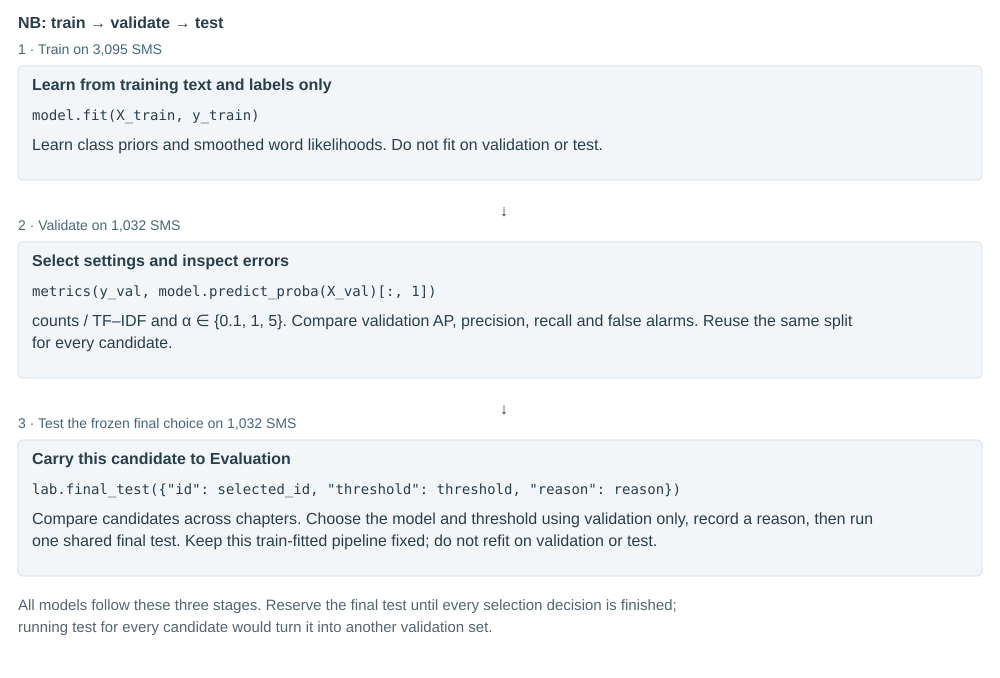

In [13]:
draw_flow(curriculum["chapters"][5]["workflow"], initial)

### Identify the training quantities and the new message

We fit on 3,095 real training messages: n_ham=2,710 and n_spam=385. Therefore π_ham=2710/3095=0.875606; π_spam=385/3095=0.124394. Unlike a balanced teaching corpus, these priors reflect the actual SMS imbalance.

The learned vocabulary has V=2,459 columns. Total retained token counts are T_ham=33,660, T_spam=7,499. Smoothing adds one to each word count and V to each class total.

New message (validation, true label ham): `Finished class where are you.`. Its retained tokens are `['finished', 'class', 'where', 'are', 'you']`. Each appears once, so each listed x_j=1; all other vocabulary columns have x_j=0. The true label is used to check the prediction, never to compute it.

### Substitute training counts into the word-likelihood formula

Every numerator below is N_cj + 1. Each denominator is T_c + V. Counts come only from training SMS; x_j comes only from the message we want to predict.

| Word | x_j | N_ham,j | N_spam,j | θ_ham,j | θ_spam,j |
| --- | --- | --- | --- | --- | --- |
| `finished` | 1 | 10 | 0 | (10+1)/(33660+2459) = 0.000305 | (0+1)/(7499+2459) = 0.000100 |
| `class` | 1 | 22 | 2 | (22+1)/(33660+2459) = 0.000637 | (2+1)/(7499+2459) = 0.000301 |
| `where` | 1 | 65 | 2 | (65+1)/(33660+2459) = 0.001827 | (2+1)/(7499+2459) = 0.000301 |
| `are` | 1 | 218 | 33 | (218+1)/(33660+2459) = 0.006063 | (33+1)/(7499+2459) = 0.003414 |
| `you` | 1 | 1070 | 152 | (1070+1)/(33660+2459) = 0.029652 | (152+1)/(7499+2459) = 0.015365 |

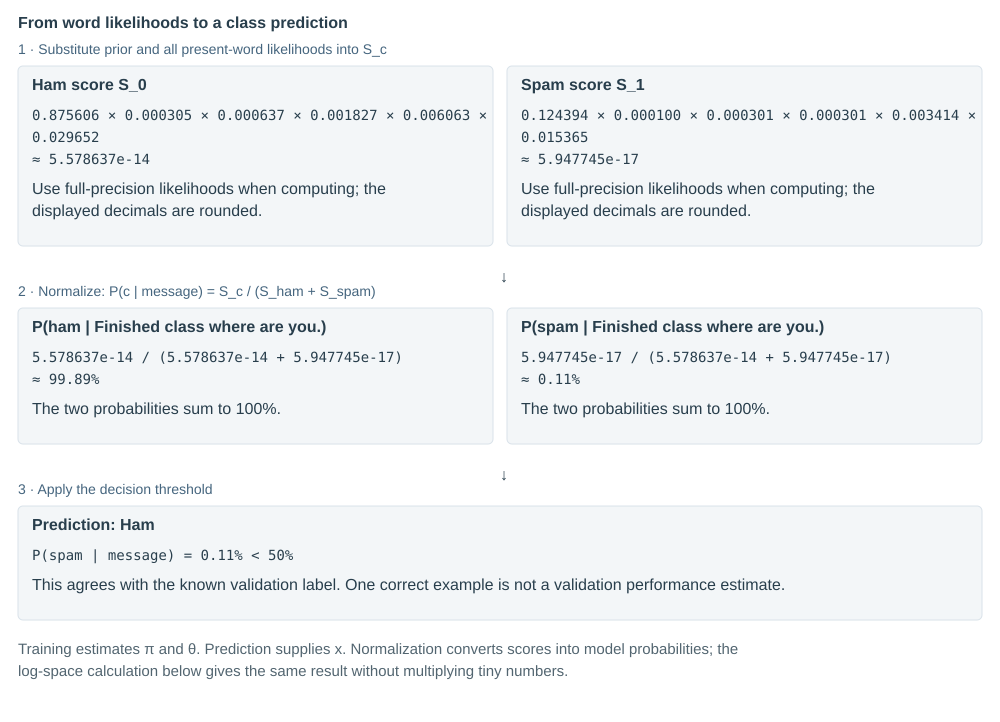

In [14]:
draw_flow(curriculum["chapters"][5]["flow"], initial)

### Inspect contribution or distance details

These priors and token counts come from a count-based NB pipeline fitted on all 3,095 training SMS, with min_df=2 and at most 2,500 words. The query is an unchanged validation SMS. Edit its counts to follow the arithmetic; validation selection and final testing are explained below.



Start with the real ham SMS below. Add claim or prize and explain how word evidence competes with the larger ham prior. Change the values in this cell and rerun to redraw the figure.

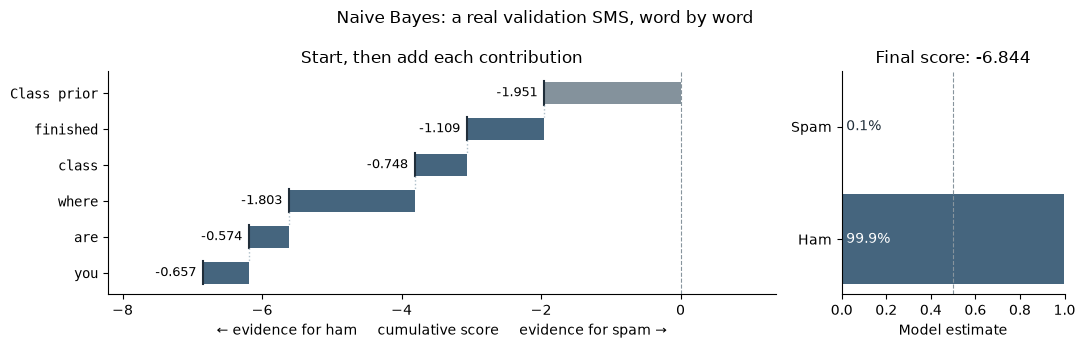

In [15]:
plot_evidence(nb_example(alpha=1), kind="nb")

[MultinomialNB documentation](https://scikit-learn.org/stable/modules/generated/sklearn.naive_bayes.MultinomialNB.html)

### Inspect learned word evidence

Keep NB fixed and compare counts with TF–IDF. TF–IDF weights are not literal counts, so compare empirically using validation average precision (AP): a precision–recall ranking summary where higher is better. Inspect a normal message containing `free`: which other words and prior evidence affect its prediction?

### Python: MultinomialNB and a representation comparison

Run the example, change one input or choice, then explain the output.

In [16]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.pipeline import Pipeline
from experiment import tokens
from sklearn.naive_bayes import MultinomialNB

candidates = []
# 1. TRAIN and VALIDATE: each setting is fitted on training SMS only.
for representation, Vectorizer in [("count", CountVectorizer), ("tfidf", TfidfVectorizer)]:
    for alpha in [.1, 1, 5]:
        model = Pipeline([
            ("vectorizer", Vectorizer(tokenizer=tokens, token_pattern=None, lowercase=False, min_df=2, max_features=2500)),
            ("classifier", MultinomialNB(alpha=alpha))
        ])
        model.fit(X_train, y_train)
        train = metrics(y_train, model.predict_proba(X_train)[:, 1])
        val = metrics(y_val, model.predict_proba(X_val)[:, 1])
        setting = {"representation": representation, "alpha": alpha}
        candidates.append({"model": model, "setting": setting, "validation": val})
        print("NB representation comparison:", setting, "train AP:", round(train["average_precision"], 3), "validation AP:", round(val["average_precision"], 3))

# 2. Select using validation AP; the fitted pipeline stays unchanged.
best = max(candidates, key=lambda row: row["validation"]["average_precision"])
model = best["model"]
print("Selected setting:", best["setting"])
print("Selected validation metrics:", best["validation"])
# 3. TEST STAGE: carry this candidate to Evaluation; choose a threshold on validation.
# Freeze one overall model and threshold there, then evaluate test exactly once.
# Do not evaluate each hyperparameter on test or retune after seeing its result.

# Explain one unchanged validation SMS using the selected pipeline.
text = X_val[273]
print("Real validation SMS:", text)
print("P(spam | SMS):", model.predict_proba([text])[0, 1])

NB representation comparison: {'representation': 'count', 'alpha': 0.1} train AP: 0.986 validation AP: 0.951


NB representation comparison: {'representation': 'count', 'alpha': 1} train AP: 0.972 validation AP: 0.952


NB representation comparison: {'representation': 'count', 'alpha': 5} train AP: 0.938 validation AP: 0.919


NB representation comparison: {'representation': 'tfidf', 'alpha': 0.1} train AP: 0.993 validation AP: 0.96


NB representation comparison: {'representation': 'tfidf', 'alpha': 1} train AP: 0.97 validation AP: 0.943


NB representation comparison: {'representation': 'tfidf', 'alpha': 5} train AP: 0.906 validation AP: 0.876
Selected setting: {'representation': 'tfidf', 'alpha': 0.1}
Selected validation metrics: {'accuracy': 0.9786821705426356, 'precision': 0.9908256880733946, 'recall': 0.8372093023255814, 'f1': 0.9075630252100841, 'confusion': [[902, 1], [21, 108]], 'false_positive_rate': 0.0011074197120708748, 'log_loss': 0.07199885388176638, 'average_precision': 0.9596538765887375, 'roc_auc': 0.9843501849991845}
Real validation SMS: Finished class where are you.
P(spam | SMS): 0.004436457908249686


### Inspect the trained model on one message

The same visual explanation now uses the fitted pipeline above. Change the message and rerun; the model stays fixed.

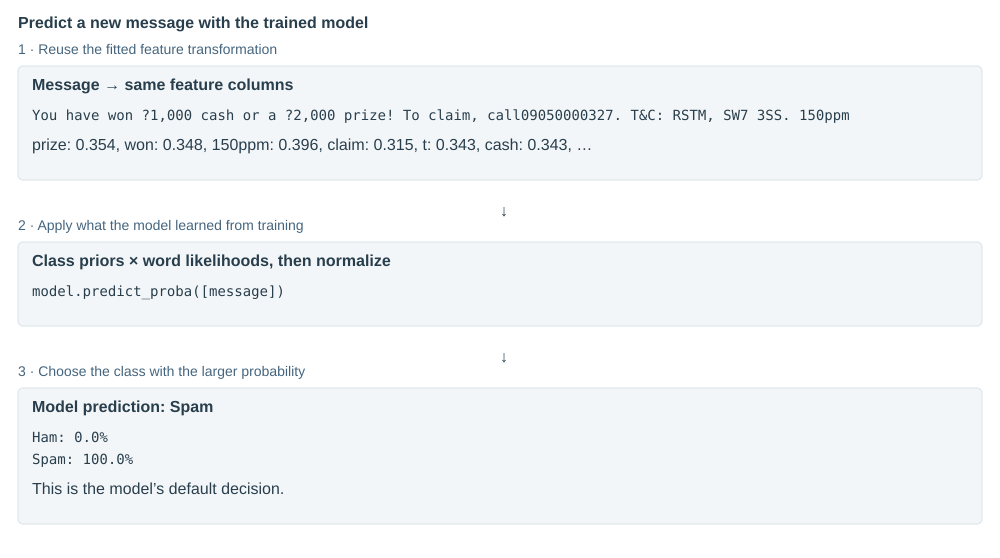

In [17]:
explanation = explain_model(model, X_val[482], X_train, y_train)
draw_flow(prediction_flow(explanation, "nb"))

### Inspect the fitted contributions or distances

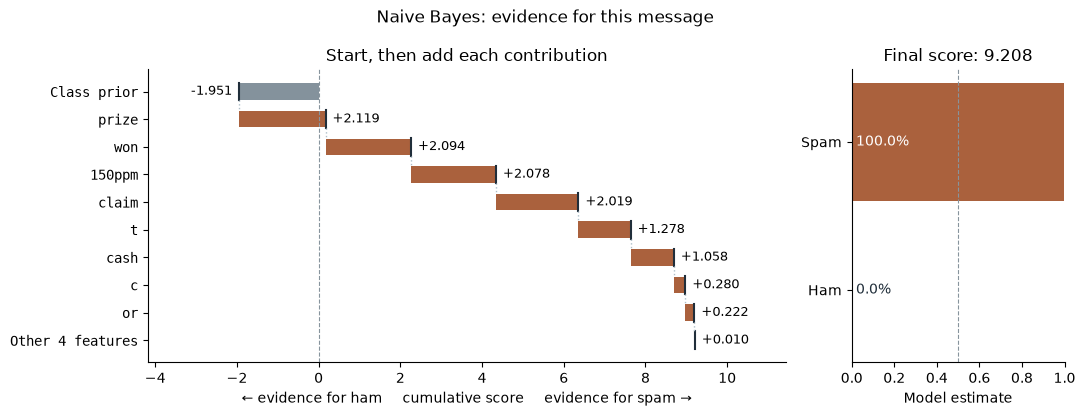

In [18]:
plot_evidence(explanation, kind="nb", title="Naive Bayes: evidence for this message")

## 7. Logistic Regression: Learning Word Weights

### How each word affects a prediction

Logistic regression learns a weight for each word feature.

- The classifier is familiar from earlier tutorials; the new part is the input matrix. Each column now represents a word instead of a measurement such as pixel intensity.
- Positive weights push towards spam; negative weights push towards ham. For one message, the contribution is weight × feature value. An absent word contributes zero.
- Hold the representation fixed when comparing LR with NB. A larger word weight alone does not guarantee a larger contribution, especially with TF–IDF.

### Formula and notation

$$z=b+\sum_j w_jx_j,\qquad p=\frac{1}{1+e^{-z}}$$

- $w_jx_j$: word j’s contribution to this message
- $b$: intercept
- $p$: model-estimated spam probability

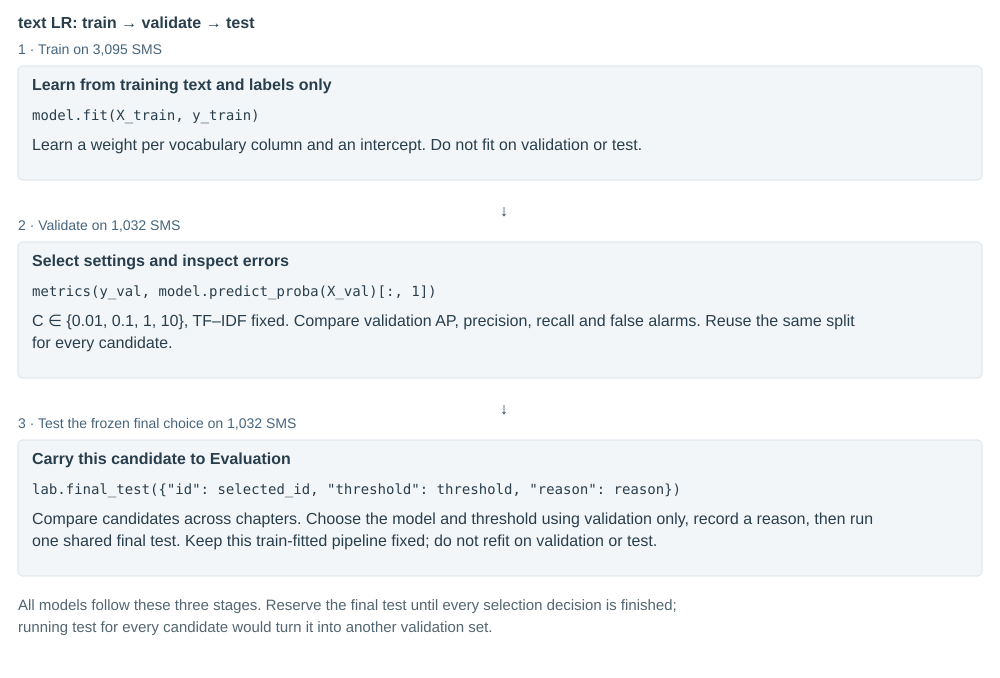

In [19]:
draw_flow(curriculum["chapters"][6]["workflow"], initial)

### Training messages → word-count vectors

Column order: `['free', 'prize', 'class', 'meet']`

| Row | Label | Message | Vector |
| --- | --- | --- | --- |
| 1 | Ham | `Yup i'm free...` | `[1, 0, 0, 0]` |
| 2 | Ham | `Ugh just got outta class` | `[0, 0, 1, 0]` |
| 3 | Ham | `Thank You meet you monday` | `[0, 0, 0, 1]` |
| 4 | Spam | `Win a £1000 cash prize or a prize worth £5000` | `[0, 2, 0, 0]` |
| 5 | Spam | `500 free text msgs. Just text ok to 80488 and we'll credit your account` | `[1, 0, 0, 0]` |
| 6 | Spam | `449050000301 You have won a £2,000 price! To claim, call 09050000301.` | `[0, 0, 0, 0]` |

### Logistic regression: train, then predict

These six unchanged messages are real training SMS. To expose every multiplication, this arithmetic view keeps four word columns and fits LR to these six rows. It is not the full fitted classifier or a performance estimate. The complete experiment below fits all training SMS, selects C on validation and reserves test.

Choose a new message. Follow its vector through the learned weights to the predicted class.

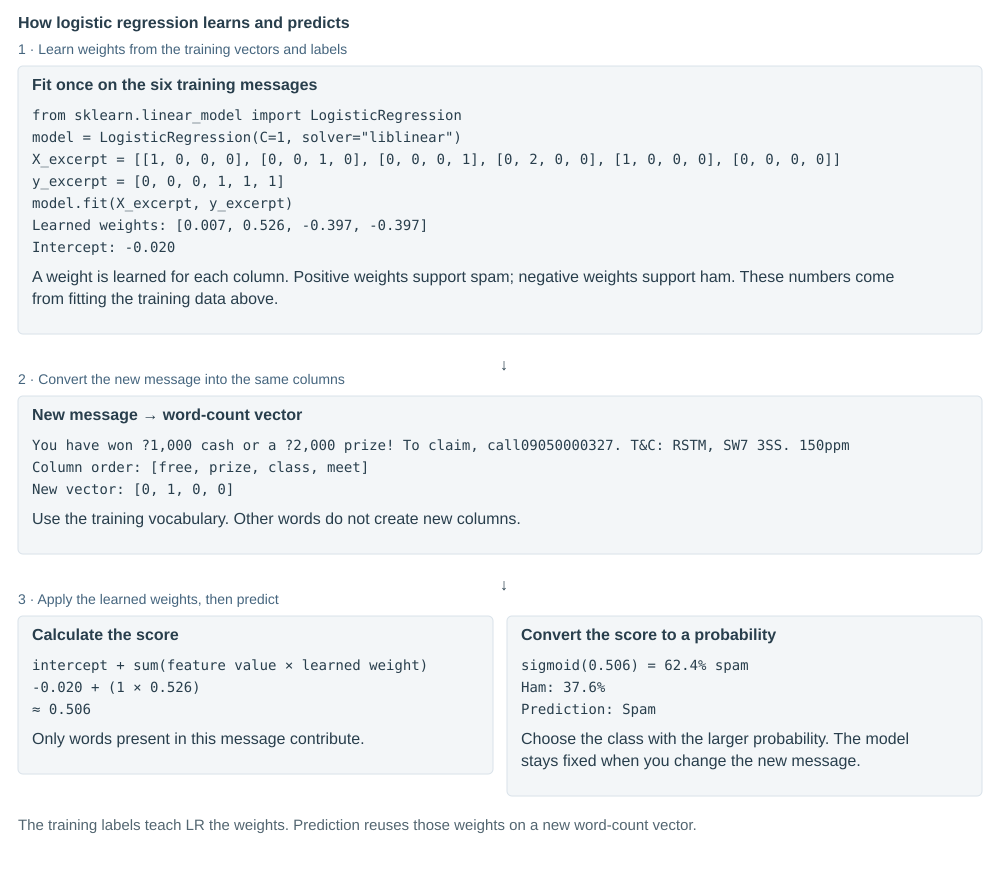

In [20]:
draw_flow(model_examples["logistic"]["flow"], lr_flow_values(**model_examples["logistic"]["queries"][0]))

### Inspect contribution or distance details



Choose a new message. Follow its vector through the learned weights to the predicted class. Change the values in this cell and rerun to redraw the figure.

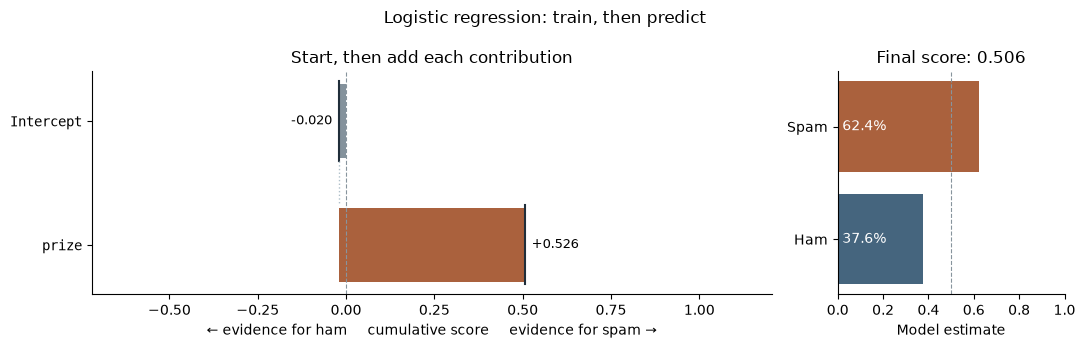

In [21]:
plot_evidence(lr_example(model_examples["logistic"]["queries"][0]["counts"]), kind="logistic")

### Change a word and inspect its contribution

Replace one word in a message and inspect the change in its contribution and prediction. Keep the representation fixed when comparing with NB.

### Python: word values, weights and contributions

Run the example, change one input or choice, then explain the output.

In [22]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.pipeline import Pipeline
from experiment import tokens
from sklearn.linear_model import LogisticRegression

candidates = []
# 1. TRAIN and VALIDATE: fixed TF–IDF; compare C on validation.
for C in [.01, .1, 1, 10]:
    model = Pipeline([
        ("vectorizer", TfidfVectorizer(tokenizer=tokens, token_pattern=None, lowercase=False, min_df=2, max_features=2500)),
        ("classifier", LogisticRegression(C=C, solver="liblinear", max_iter=1000, random_state=3612))
    ])
    model.fit(X_train, y_train)
    train = metrics(y_train, model.predict_proba(X_train)[:, 1])
    val = metrics(y_val, model.predict_proba(X_val)[:, 1])
    candidates.append({"model": model, "setting": {"C": C}, "validation": val})
    print("C:", C, "train AP:", round(train["average_precision"], 3), "validation AP:", round(val["average_precision"], 3))

# 2. Select using validation AP; the fitted pipeline stays unchanged.
best = max(candidates, key=lambda row: row["validation"]["average_precision"])
model = best["model"]
print("Selected setting:", best["setting"])
print("Selected validation metrics:", best["validation"])
# 3. TEST STAGE: carry this candidate to Evaluation; choose a threshold on validation.
# Freeze one overall model and threshold there, then evaluate test exactly once.
# Do not evaluate each hyperparameter on test or retune after seeing its result.

message = X_val[482]
names = model.named_steps["vectorizer"].get_feature_names_out()
weights = model.named_steps["classifier"].coef_[0]
values = model.named_steps["vectorizer"].transform([message]).toarray()[0]
print("LR prediction:", message, "→", model.predict_proba([message])[0, 1])
for j in np.flatnonzero(values):
    print(names[j], "value:", round(values[j], 3), "weight:", round(weights[j], 3), "contribution:", round(values[j] * weights[j], 3))

C: 0.01 train AP: 0.944 validation AP: 0.935


C: 0.1 train AP: 0.959 validation AP: 0.948


C: 1 train AP: 0.982 validation AP: 0.958


C: 10 train AP: 0.998 validation AP: 0.962
Selected setting: {'C': 10}
Selected validation metrics: {'accuracy': 0.9825581395348837, 'precision': 0.9911504424778761, 'recall': 0.8682170542635659, 'f1': 0.9256198347107438, 'confusion': [[902, 1], [17, 112]], 'false_positive_rate': 0.0011074197120708748, 'log_loss': 0.07205524291362833, 'average_precision': 0.9617221150200289, 'roc_auc': 0.9861014533810639}
LR prediction: You have won ?1,000 cash or a ?2,000 prize! To claim, call09050000327. T&C: RSTM, SW7 3SS. 150ppm → 0.9975988104003367
150ppm value: 0.396 weight: 1.295 contribution: 0.513
a value: 0.165 weight: 3.013 contribution: 0.496
c value: 0.314 weight: 3.263 contribution: 1.023
cash value: 0.343 weight: 2.469 contribution: 0.847
claim value: 0.315 weight: 5.014 contribution: 1.578
have value: 0.211 weight: 0.338 contribution: 0.071
or value: 0.229 weight: 3.531 contribution: 0.808
prize value: 0.354 weight: 2.831 contribution: 1.003
t value: 0.343 weight: 3.114 contribution: 1.

### Inspect the trained model on one message

The same visual explanation now uses the fitted pipeline above. Change the message and rerun; the model stays fixed.

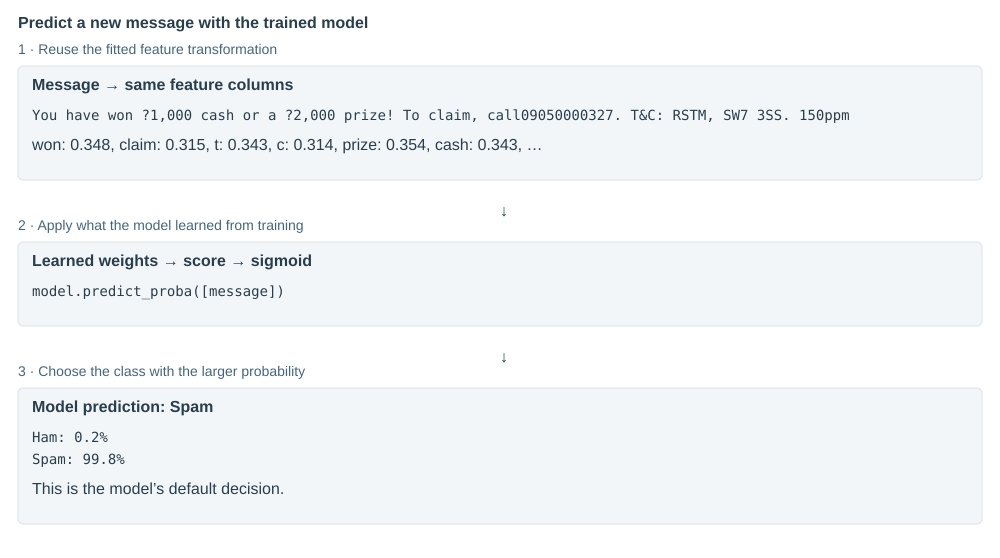

In [23]:
explanation = explain_model(model, X_val[482], X_train, y_train)
draw_flow(prediction_flow(explanation, "logistic"))

### Inspect the fitted contributions or distances

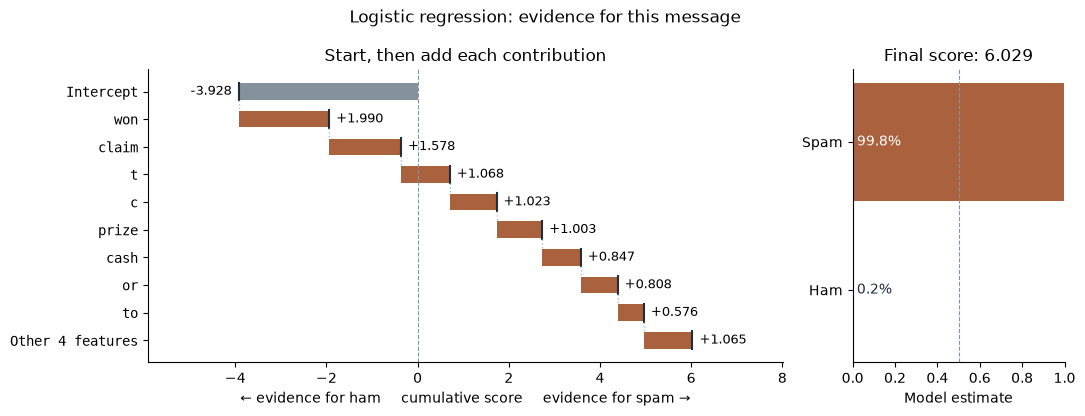

In [24]:
plot_evidence(explanation, kind="logistic", title="Logistic regression: evidence for this message")

## 8. KNN: Voting from Similar Messages

### Similar vectors, neighbouring labels

KNN predicts from the labels of nearby training messages.

- Use TF–IDF vectors and cosine distance to compare their directions. A small distance means similar word-weight patterns, not necessarily similar meaning.
- KNN stores the training examples. With uniform voting, its spam score is the proportion of spam among the k neighbours.
- Inspect the actual neighbours. A message with no known words has a zero vector, so word-based similarity offers little useful evidence.

### Formula and notation

$$\begin{aligned}d_2(\mathbf x,\mathbf z)&=\sqrt{\sum_j(x_j-z_j)^2}\\d_1(\mathbf x,\mathbf z)&=\sum_j|x_j-z_j|\\d_{\cos}(\mathbf x,\mathbf z)&=1-\frac{\mathbf x^\top\mathbf z}{\|\mathbf x\|_2\|\mathbf z\|_2}\\\hat p(\mathbf x)&=\frac{1}{k}\sum_{i\in N_k(\mathbf x)}y_i\end{aligned}$$

- $\mathbf x,\mathbf z$: query and training vectors in the same feature columns
- $d_2,\ d_1,\ d_{\cos}$: Euclidean, Manhattan and cosine distances; smaller is nearer
- $k$: number of nearest training messages; selected on validation
- $N_k(\mathbf x)$: indices of the k smallest training distances
- $y_i$: known training label (1=spam, 0=ham); not the query label

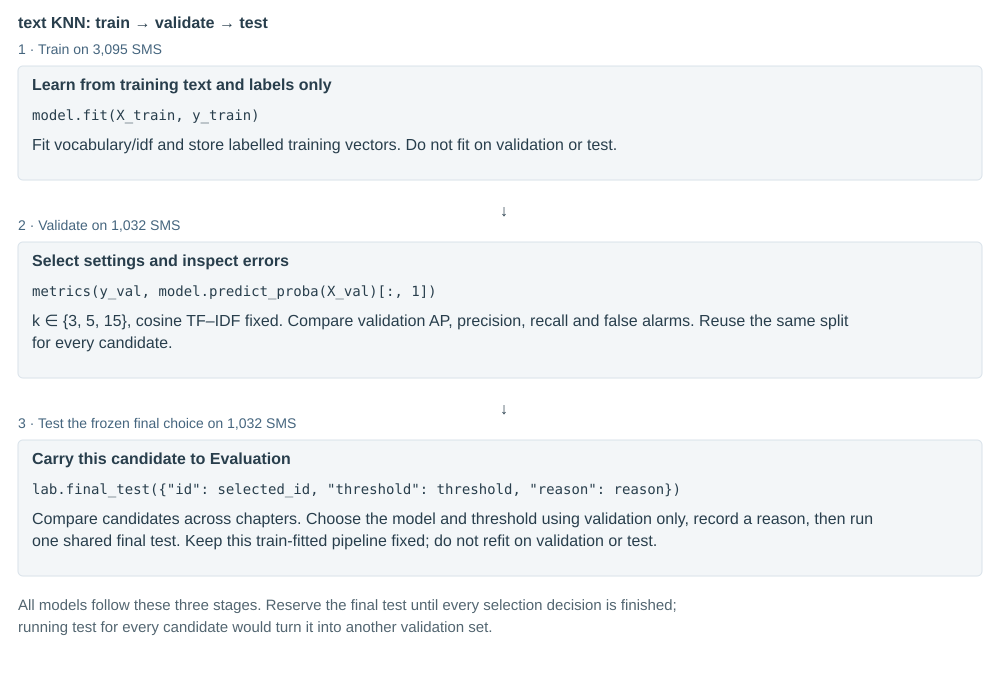

In [25]:
draw_flow(curriculum["chapters"][7]["workflow"], initial)

### Which distance should we use?

Choose a metric that matches the representation, then compare plausible choices on validation. Scaling and TF–IDF fitting still belong inside the training pipeline.

| Distance | Use when | Care needed |
| --- | --- | --- |
| Cosine | Sparse word counts / TF–IDF: relative word patterns matter more than SMS length. This is our text KNN metric. | Undefined direction for zero vectors; ignores total magnitude; word similarity is not semantic similarity. |
| Euclidean (L2) | Continuous numerical features where a straight-line difference has meaning; standardize our five log-count features first. | Large-scale columns dominate without training-fitted scaling. For unit-L2 text vectors, d₂² = 2 d_cos, so rankings agree. |
| Manhattan (L1) | Numerical features when absolute per-coordinate differences should add; less amplification of one large coordinate gap than L2. | Scale columns on train; suitability and k still require validation. |

### Calculate three distances for the same vectors

Use the two columns `[prize, call]`. A real training spam SMS has `[2,0]`: `Win a £1000 cash prize or a prize worth £5000`. A real validation spam SMS has `[1,0]` in these columns. We use raw counts for L1/L2 and the cosine formula for directions.

For a second direction `[0,1]` (a real ham SMS asking for a call), calculate again. The same two columns must be used for every message.

The vector `[1,1]` also occurs in a real training SMS: `URGENT! Your Mobile number has been awarded with a £2000 prize GUARANTEED. Call 09058094455 from land line. Claim 3030. Valid 12hrs only`. Its two selected word counts are one prize and one call.

| Query x | Training z | Euclidean | Manhattan | Cosine |
| --- | --- | --- | --- | --- |
| [1,0] | [2,0] | sqrt((1−2)² + (0−0)²) = 1 | \|1−2\| + \|0−0\| = 1 | 1 − 2/(1 × 2) = 0 |
| [1,0] | [0,1] | sqrt(1² + (−1)²) = √2 ≈ 1.414 | \|1\| + \|−1\| = 2 | 1 − 0/(1 × 1) = 1 |
| [1,1] | [2,0] | √2 ≈ 1.414 | 2 | 1 − 2/(√2 × 2) ≈ 0.293 |

### From distances to the selected neighbours

Compute distances to every training vector, sort ascending, select exactly the first k, then count only their training labels. The diagram below circles the selected points and draws connections to the query. Overlapping directions can contain several messages; the ranking lists them separately.

Small k is sensitive to individual examples. Large k includes less relevant messages and can favor ham. Select k using validation AP and errors. The vote fraction is a local label proportion, not a calibrated certainty.

### Training messages → word-count vectors

Column order: `['prize', 'call']`

| Row | Label | Message | Vector |
| --- | --- | --- | --- |
| 1 | Spam | `Win a £1000 cash prize or a prize worth £5000` | `[2, 0]` |
| 2 | Spam | `You have won ?1,000 cash or a ?2,000 prize! To claim, call09050000327` | `[1, 0]` |
| 3 | Spam | `URGENT! Your Mobile number has been awarded with a £2000 prize GUARANTEED. Call 09058094455 from land line. Claim 3030. Valid 12hrs only` | `[1, 1]` |
| 4 | Ham | `Once free call me sir.` | `[0, 1]` |
| 5 | Ham | `Now am free call me pa.` | `[0, 1]` |
| 6 | Ham | `I am waiting machan. Call me once you free.` | `[0, 1]` |

### KNN: find neighbours, then vote

These are six unchanged training SMS. We keep prize and call only to draw exact two-dimensional directions. Different SMS can collapse to the same point, even with different labels: a useful warning about information lost by the representation. The full experiment uses all training messages and all learned TF–IDF columns, with k chosen on validation.

Choose a real validation SMS and follow its distance ranking. Changing k changes which training messages vote. Words outside the two displayed columns are ignored in this calculation.

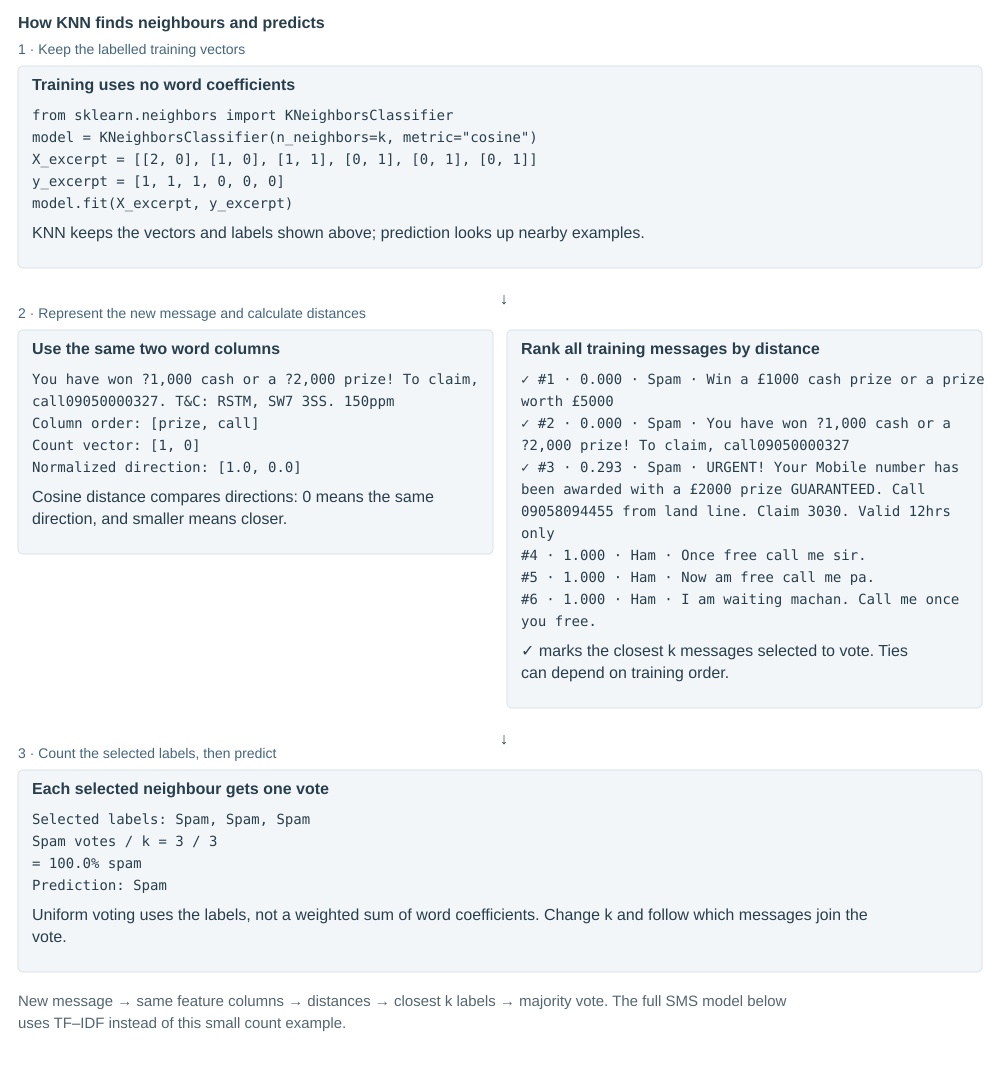

In [26]:
draw_flow(model_examples["knn"]["flow"], knn_flow_values(k=3, **model_examples["knn"]["queries"][0]))

### Inspect contribution or distance details



Choose a real validation SMS and follow its distance ranking. Changing k changes which training messages vote. Words outside the two displayed columns are ignored in this calculation. Change the values in this cell and rerun to redraw the figure.

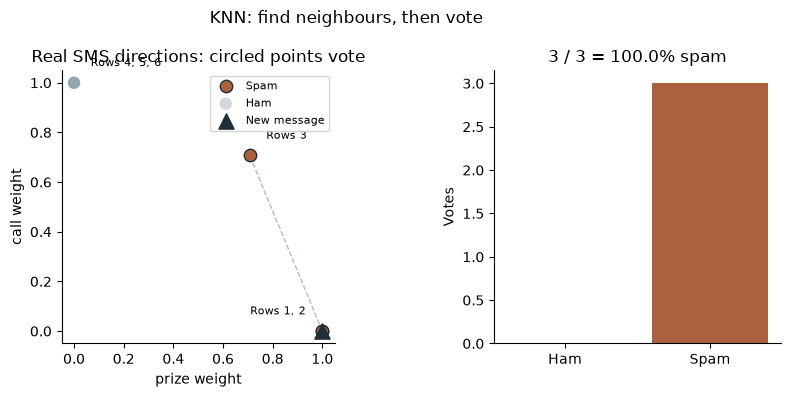

In [27]:
plot_neighbors(knn_example(counts=(1, 0), k=3))  # Counts: prize, call

### Read the messages that voted

Compare k = 3 with k = 15. Read the additional neighbours and explain the change in the vote.

### Python: cosine neighbours and the spam vote

Run the example, change one input or choice, then explain the output.

In [28]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.pipeline import Pipeline
from experiment import tokens
from sklearn.neighbors import KNeighborsClassifier

candidates = []
# 1. TRAIN and VALIDATE: compare k, holding TF–IDF and cosine distance fixed.
for k in [3, 5, 15]:
    model = Pipeline([
        ("vectorizer", TfidfVectorizer(tokenizer=tokens, token_pattern=None, lowercase=False, min_df=2, max_features=2500)),
        ("classifier", KNeighborsClassifier(n_neighbors=k, metric="cosine", algorithm="brute"))
    ])
    model.fit(X_train, y_train)
    train = metrics(y_train, model.predict_proba(X_train)[:, 1])
    val = metrics(y_val, model.predict_proba(X_val)[:, 1])
    candidates.append({"model": model, "setting": {"k": k}, "validation": val})
    print("k:", k, "train AP:", round(train["average_precision"], 3), "validation AP:", round(val["average_precision"], 3))

# 2. Select using validation AP; the fitted pipeline stays unchanged.
best = max(candidates, key=lambda row: row["validation"]["average_precision"])
model = best["model"]
print("Selected setting:", best["setting"])
print("Selected validation metrics:", best["validation"])
# 3. TEST STAGE: carry this candidate to Evaluation; choose a threshold on validation.
# Freeze one overall model and threshold there, then evaluate test exactly once.
# Do not evaluate each hyperparameter on test or retune after seeing its result.

text = X_val[482]
vector = model.named_steps["vectorizer"].transform([text])
distances, indices = model.named_steps["classifier"].kneighbors(vector)
print("Real validation SMS:", text)
for distance, index in zip(distances[0], indices[0]):
    print(round(distance, 3), "spam" if y_train[index] else "ham", "|", X_train[index])
print("Spam vote:", model.predict_proba([text])[0, 1])

k: 3 train AP: 0.975 validation AP: 0.87


k: 5 train AP: 0.97 validation AP: 0.899


k: 15 train AP: 0.965 validation AP: 0.934
Selected setting: {'k': 15}
Selected validation metrics: {'accuracy': 0.9612403100775194, 'precision': 1.0, 'recall': 0.689922480620155, 'f1': 0.81651376146789, 'confusion': [[903, 0], [40, 89]], 'false_positive_rate': 0.0, 'log_loss': 0.1951537767073493, 'average_precision': 0.9341750696136081, 'roc_auc': 0.9758427979087795}
Real validation SMS: You have won ?1,000 cash or a ?2,000 prize! To claim, call09050000327. T&C: RSTM, SW7 3SS. 150ppm
0.208 spam | You have won ?1,000 cash or a ?2,000 prize! To claim, call09050000327
0.446 spam | URGENT! Last weekend's draw shows that you have won £1000 cash or a Spanish holiday! CALL NOW 09050000332 to claim. T&C: RSTM, SW7 3SS. 150ppm
0.523 spam | URGENT! You have won a 1 week FREE membership in our £100,000 Prize Jackpot! Txt the word: CLAIM to No: 81010 T&C www.dbuk.net LCCLTD POBOX 4403LDNW1A7RW18
0.525 spam | You have WON a guaranteed £1000 cash or a £2000 prize. To claim yr prize call our custome

### Inspect the trained model on one message

The same visual explanation now uses the fitted pipeline above. Change the message and rerun; the model stays fixed.

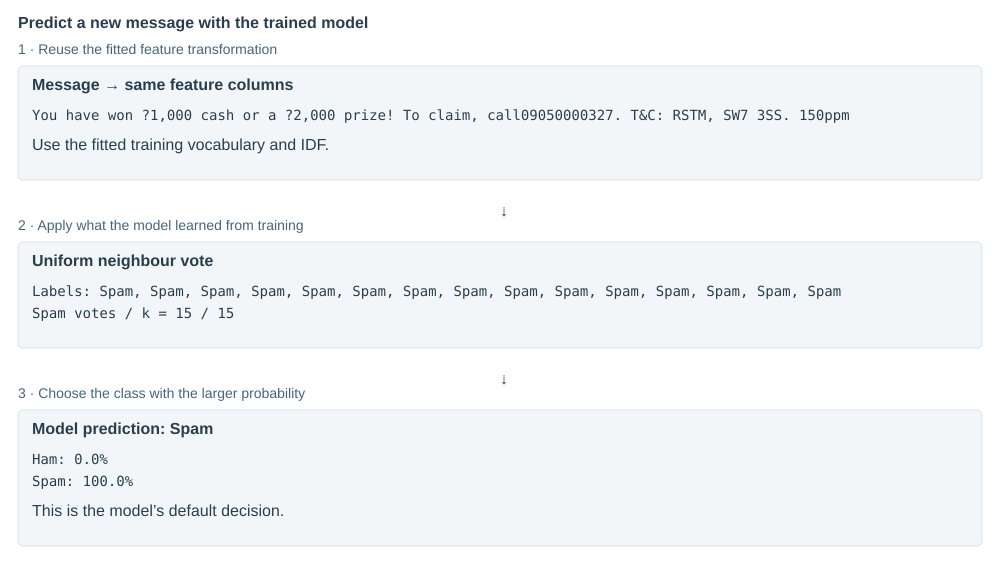

In [29]:
explanation = explain_model(model, X_val[482], X_train, y_train)
draw_flow(prediction_flow(explanation, "knn"))

### Inspect the fitted contributions or distances

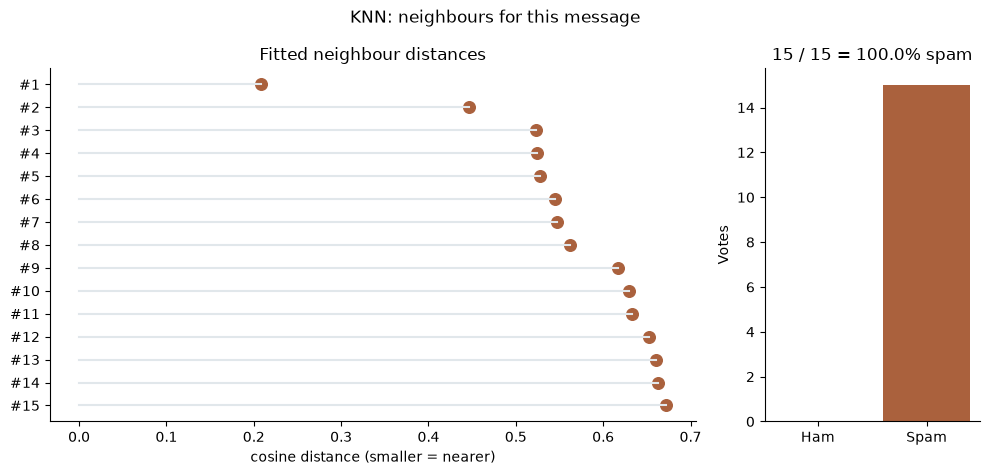

In [30]:
plot_neighbors(explanation, title="KNN: neighbours for this message")

## 9. Regularization: Controlling Word Weights

### Shrink weights to reduce overfitting

With thousands of word features, rare training coincidences can receive large weights. Return to the LR model and changes only its penalty strength.

- Keep the same TF–IDF representation as the text LR chapter. Compare training and validation performance across C on the same SMS splits.
- The L2 penalty shrinks weights towards 0. In sklearn, smaller `C` means a stronger penalty.
- Too strong: the model underfits. Too weak: it memorizes training noise. Watch the gap between training and validation.

### Formula and notation

$$C\downarrow\ \Rightarrow\ \text{stronger L2 penalty}\ \Rightarrow\ \text{smaller fitted weights}$$

- $C$: inverse regularization strength in sklearn

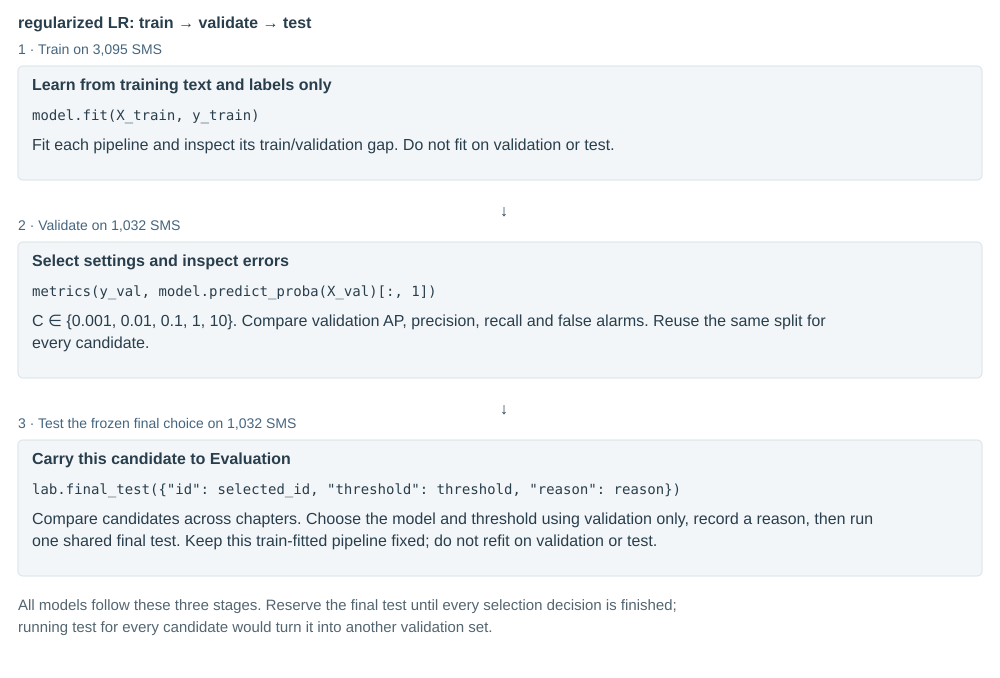

In [31]:
draw_flow(curriculum["chapters"][8]["workflow"], initial)

### Reading the training–validation gap

A training improvement without a validation improvement suggests overfitting. AP summarizes precision–recall ranking; the coefficient norm summarizes weight size. A real dataset need not show a textbook U-shaped validation curve.

### Compare weights and performance across C

Which C gives the best validation AP? Did larger weights help?

### Python: a regularization sweep

Run the example, change one input or choice, then explain the output.

In [32]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from experiment import tokens

for C in [.001, .01, .1, 1, 10]:
    model = Pipeline([
        ("vectorizer", TfidfVectorizer(tokenizer=tokens, token_pattern=None, lowercase=False, min_df=2, max_features=2500)),
        ("classifier", LogisticRegression(C=C, solver="liblinear", max_iter=1000, random_state=3612))
    ])
    model.fit(X_train, y_train)
    train = metrics(y_train, model.predict_proba(X_train)[:, 1])["average_precision"]
    val = metrics(y_val, model.predict_proba(X_val)[:, 1])["average_precision"]
    norm = np.linalg.norm(model.named_steps["classifier"].coef_)
    print(f"C={C:g}, weight norm={norm:.3f}, train AP={train:.3f}, validation AP={val:.3f}")

C=0.001, weight norm=0.131, train AP=0.675, validation AP=0.670


C=0.01, weight norm=0.727, train AP=0.944, validation AP=0.935


C=0.1, weight norm=5.335, train AP=0.959, validation AP=0.948


C=1, weight norm=19.367, train AP=0.982, validation AP=0.958


C=10, weight norm=45.009, train AP=0.998, validation AP=0.962


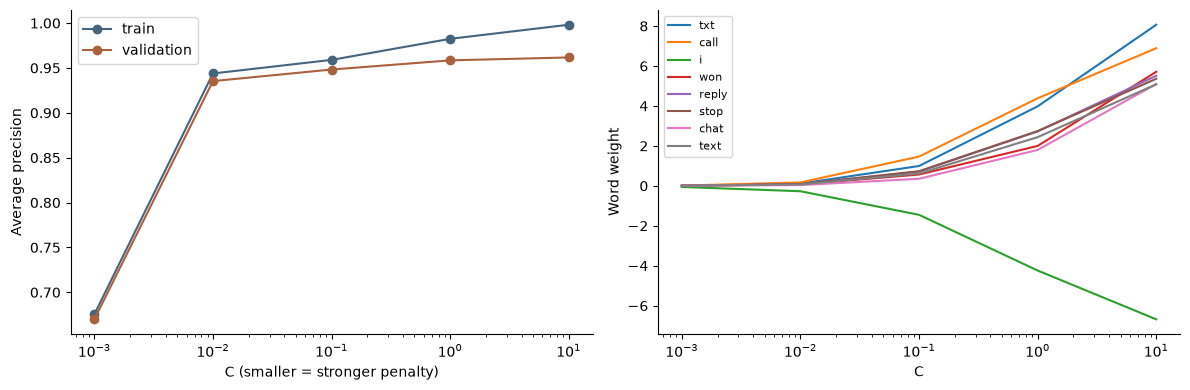

In [33]:
path_result = lab.regularization({"representation": "tfidf"})
Cs = [row["C"] for row in path_result["rows"]]
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for split, color in [("train", HAM), ("validation", SPAM)]:
    axes[0].semilogx(Cs, [row[split]["average_precision"] for row in path_result["rows"]], "o-", label=split, color=color)
axes[0].set(xlabel="C (smaller = stronger penalty)", ylabel="Average precision")
axes[0].legend()
for item in path_result["paths"]:
    axes[1].semilogx(Cs, item["weights"], label=item["word"])
axes[1].set(xlabel="C", ylabel="Word weight")
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

## 10. Cross-Validation: Choosing C without Leakage

### Refit every learned step inside each fold

Cross-validation compares choices on held-out folds of the training set.

- Split training messages into five folds: fit on four, score the fifth, rotate and average.
- Keep vocabulary, IDF and classifier inside `Pipeline`: each fold must learn all three using its own training portion.
- `GridSearchCV` selects the best mean AP, then refits the full pipeline on all training messages. The final test set is never involved.

### Formula and notation

$$\mathrm{CV}(C)=\frac{1}{5}\sum_{f=1}^{5}\mathrm{AP}_f(C)$$

- $f$: the held-out fold
- $\mathrm{AP}_f(C)$: average precision on fold f; the pipeline is fitted without it
- $\mathrm{AP}$: area-like summary of the precision–recall curve

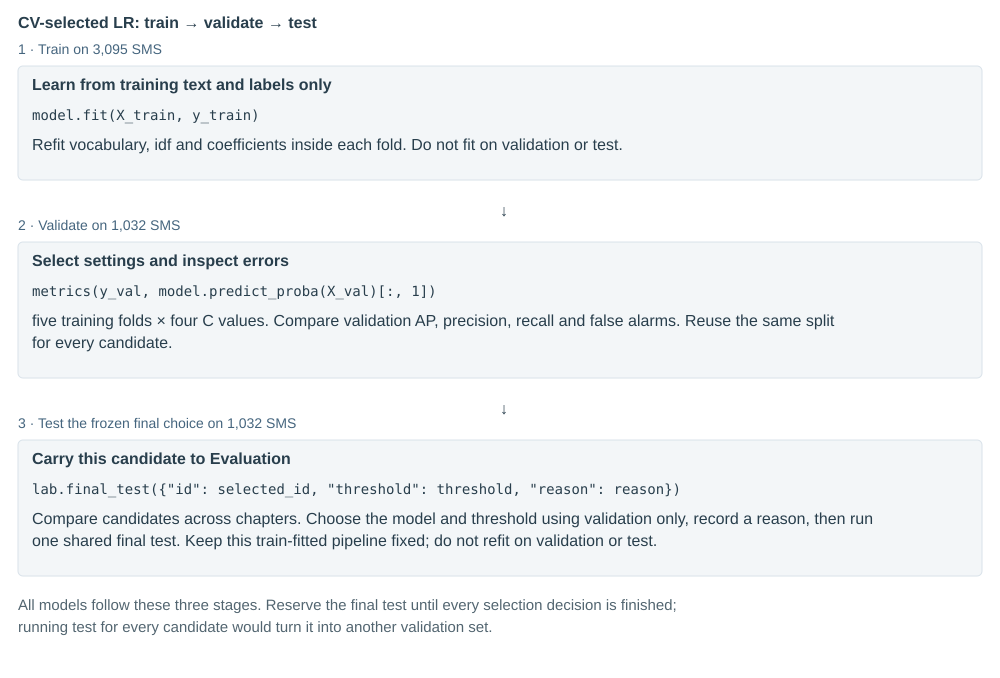

In [34]:
draw_flow(curriculum["chapters"][9]["workflow"], initial)

### Inspect training folds and compare C

Why can the vocabulary size differ between folds, and why is that correct?

### Python: Pipeline and GridSearchCV

Run the example, change one input or choice, then explain the output.

In [35]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from experiment import tokens

model = Pipeline([
    ("vectorizer", TfidfVectorizer(tokenizer=tokens, token_pattern=None, lowercase=False, min_df=2, max_features=2500)),
    ("classifier", LogisticRegression(solver="liblinear", max_iter=1000, random_state=3612))
])
folds = StratifiedKFold(n_splits=5, shuffle=True, random_state=3612)
search = GridSearchCV(model, {"classifier__C": [.01, .1, 1, 10]}, cv=folds, scoring="average_precision")
search.fit(X_train, y_train)
print("Selected C:", search.best_params_["classifier__C"])
for params, mean, std in zip(search.cv_results_["params"], search.cv_results_["mean_test_score"], search.cv_results_["std_test_score"]):
    print(params, "mean AP:", round(mean, 3), "SD:", round(std, 3))
model = search.best_estimator_
print("Full training AP:", metrics(y_train, model.predict_proba(X_train)[:, 1])["average_precision"])
print("Independent validation AP:", metrics(y_val, model.predict_proba(X_val)[:, 1])["average_precision"])
# Carry this CV-selected candidate to the shared final test after validation comparison.

Selected C: 10
{'classifier__C': 0.01} mean AP: 0.921 SD: 0.021
{'classifier__C': 0.1} mean AP: 0.941 SD: 0.018
{'classifier__C': 1} mean AP: 0.955 SD: 0.017
{'classifier__C': 10} mean AP: 0.96 SD: 0.015
Full training AP: 0.9981733503150839


Independent validation AP: 0.9617221150200289


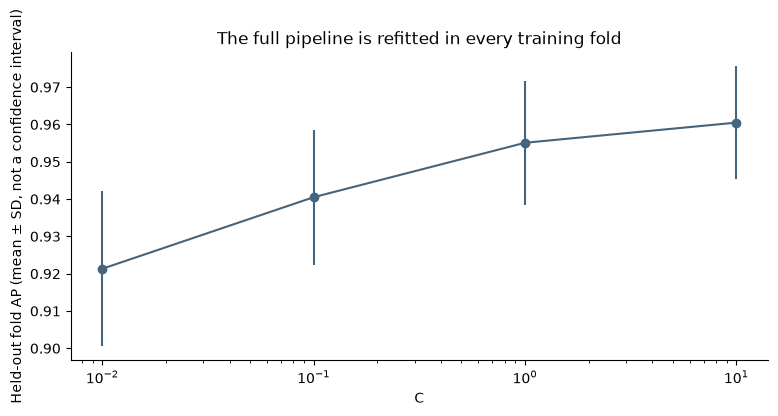

In [36]:
means = search.cv_results_["mean_test_score"]
std = search.cv_results_["std_test_score"]
Cs = [p["classifier__C"] for p in search.cv_results_["params"]]
plt.errorbar(Cs, means, yerr=std, fmt="o-", color=HAM)
plt.xscale("log")
plt.xlabel("C")
plt.ylabel("Held-out fold AP (mean ± SD, not a confidence interval)")
plt.title("The full pipeline is refitted in every training fold")
plt.show()

## 11. Numerical Features: Measuring a Message

### Five measurements instead of word identity

Word vectors are one representation. For LDA and GAM, we instead measure five properties of each message.

- Measure characters, retained NLTK tokens, links, digits and exclamation marks.
- Spam tends to be longer and to contain more digits (prices, phone numbers), but the two classes overlap.
- Counts are skewed, so take log(1+x), then standardize with the training mean and standard deviation.
- These five counts discard word identity: very different messages can have the same measurements. Compare numerical LR, LDA and GAM on these same inputs.

### Formula and notation

$$u_j=\log(1+x_j),\qquad z_j=\frac{u_j-\mu_j}{s_j}$$

- $x_j$: raw count, e.g. number of digits
- $\mu_j,\ s_j$: mean and SD from training data only
- $z_j$: the value the model sees

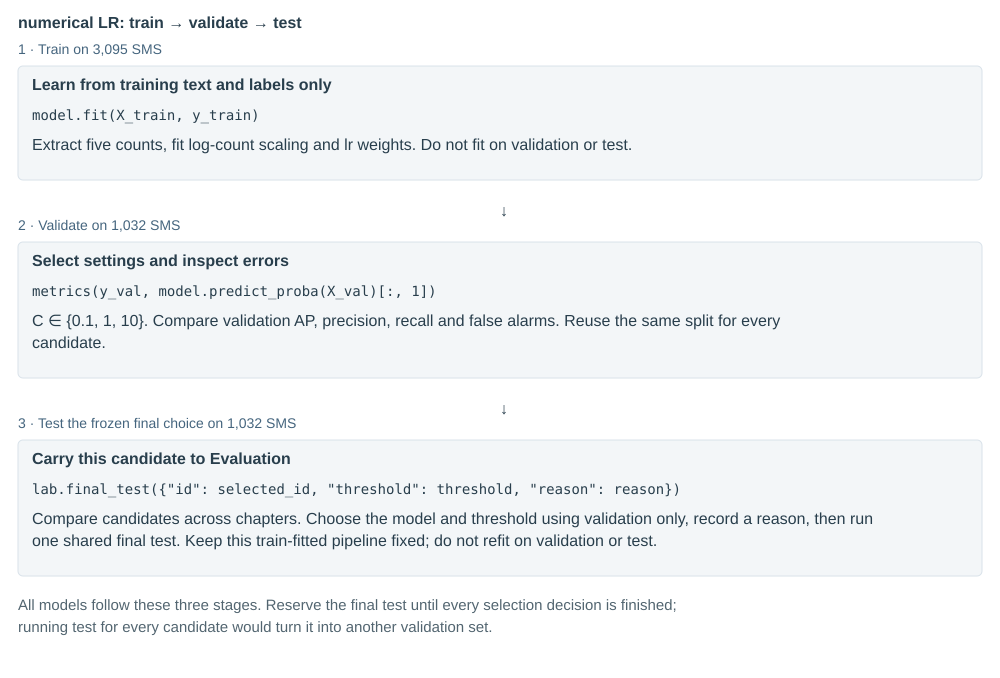

In [37]:
draw_flow(curriculum["chapters"][10]["workflow"], initial)

### Scale one real validation SMS using training statistics

Validation SMS (true label spam): `You have won ?1,000 cash or a ?2,000 prize! To claim, call09050000327. T&C: RSTM, SW7 3SS. 150ppm`. Measure the five raw counts first. The true label does not enter this transformation.

Take log(1+count), then subtract each training mean and divide by its training standard deviation. The mean and SD below are learned from all 3,095 training messages, not from this validation row.

| Feature | Raw count | log(1+x) | Training mean μ | Training SD s | Standardized z |
| --- | --- | --- | --- | --- | --- |
| Characters | 97 | 4.585 | 4.149 | 0.701 | 0.622 |
| Tokens | 14 | 2.708 | 2.540 | 0.630 | 0.268 |
| Links | 0 | 0.000 | 0.013 | 0.100 | -0.132 |
| Digits | 24 | 3.219 | 0.452 | 0.927 | 2.984 |
| Exclamation marks | 1 | 0.693 | 0.132 | 0.330 | 1.699 |

### Measure messages and compare their distributions

Write two very different messages with the same five numbers. What can this representation not see?

### Python: measurements, scaling and numerical LR

Run the example, change one input or choice, then explain the output.

In [38]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, StandardScaler
from sklearn.linear_model import LogisticRegression
from experiment import numerical_features

texts = [X_train[47], X_train[1544]]
print("Characters, words, links, digits, exclamations:")
print(numerical_features(texts))
candidates = []
for C in [.1, 1, 10]:
    model = Pipeline([
        ("features", FunctionTransformer(numerical_features)),
        ("log", FunctionTransformer(np.log1p)),
        ("scale", StandardScaler()),
        ("classifier", LogisticRegression(C=C, solver="liblinear", max_iter=1000, random_state=3612))
    ])
    model.fit(X_train, y_train)
    train = metrics(y_train, model.predict_proba(X_train)[:, 1])
    val = metrics(y_val, model.predict_proba(X_val)[:, 1])
    candidates.append({"model": model, "setting": {"C": C}, "validation": val})
    print("Numerical baseline AP:", C, "train:", round(train["average_precision"], 3), "validation:", round(val["average_precision"], 3))

# 2. Select using validation AP; the fitted pipeline stays unchanged.
best = max(candidates, key=lambda row: row["validation"]["average_precision"])
model = best["model"]
print("Selected setting:", best["setting"])
print("Selected validation metrics:", best["validation"])
# 3. TEST STAGE: carry this candidate to Evaluation; choose a threshold on validation.
# Freeze one overall model and threshold there, then evaluate test exactly once.
# Do not evaluate each hyperparameter on test or retune after seeing its result.

Characters, words, links, digits, exclamations:
[[15.  3.  0.  0.  0.]
 [45.  8.  0.  8.  0.]]


Numerical baseline AP: 0.1 train: 0.947 validation: 0.946


Numerical baseline AP: 1 train: 0.947 validation: 0.945


Numerical baseline AP: 10 train: 0.947 validation: 0.944
Selected setting: {'C': 0.1}
Selected validation metrics: {'accuracy': 0.9767441860465116, 'precision': 0.9487179487179487, 'recall': 0.8604651162790697, 'f1': 0.9024390243902439, 'confusion': [[897, 6], [18, 111]], 'false_positive_rate': 0.006644518272425249, 'log_loss': 0.08648570533412221, 'average_precision': 0.9458242907931079, 'roc_auc': 0.9800492758848626}


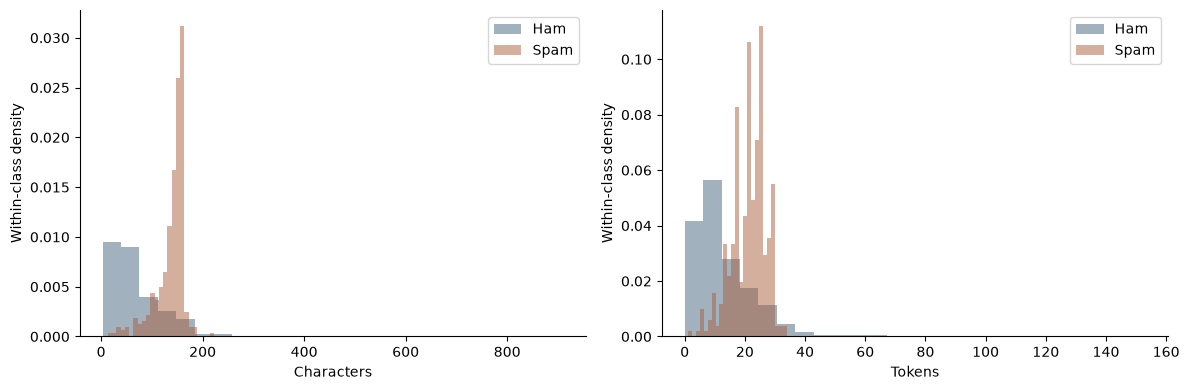

In [39]:
values = numerical_features(X_train)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for j, ax in enumerate(axes):
    for label, color in [(0, HAM), (1, SPAM)]:
        ax.hist(values[y_train == label, j], bins=25, density=True, alpha=.5, color=color, label="Ham" if label == 0 else "Spam")
    ax.set(xlabel=["Characters", "Tokens"][j], ylabel="Within-class density")
    ax.legend()
plt.tight_layout()
plt.show()

## 12. LDA: Modelling Each Class Distribution

### Gaussian classes with a shared covariance

LDA models the feature distribution within each class. We apply it to the five numerical features rather than sparse word counts.

- LDA assumes a Gaussian distribution per class, with different means and a shared covariance. The shared covariance produces a linear boundary.
- Class priors reflect the ham/spam imbalance and affect the decision boundary.
- Use five log-transformed, standardized measurements. These Gaussian assumptions are more plausible here than for thousands of sparse word counts.

### Formula and notation

$$\log\frac{P(\text{spam}\mid\mathbf x)}{P(\text{ham}\mid\mathbf x)}=(\boldsymbol\mu_1-\boldsymbol\mu_0)^\top\Sigma^{-1}\mathbf x+b$$

- $\boldsymbol\mu_0,\boldsymbol\mu_1$: class means (ham, spam)
- $\Sigma$: shared covariance
- $b$: includes the log prior ratio

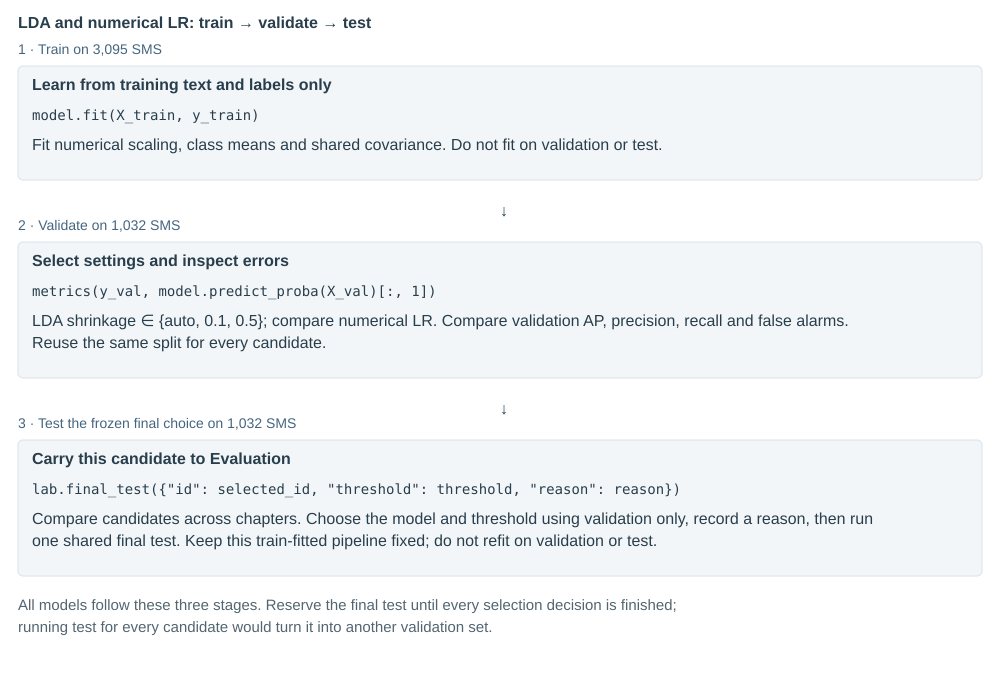

In [40]:
draw_flow(curriculum["chapters"][11]["workflow"], initial)

### From real class means to the LDA score

This worked pipeline uses shrinkage="auto" and all training SMS. Priors are ham=0.8756, spam=0.1244. The means below describe the five standardized log-count features within each training class.

Apply it to the same validation SMS: `You have won ?1,000 cash or a ?2,000 prize! To claim, call09050000327. T&C: RSTM, SW7 3SS. 150ppm`. The shared covariance transforms the difference in class means into linear weights: w = Σ⁻¹(μ_spam − μ_ham). The fitted intercept is b=-12.4077; it contains the class-mean and prior terms.

Add b and all five w_j z_j contributions: score=17.8038. The sigmoid gives P(spam | SMS)=100.00%. This is one prediction; compare shrinkage settings on the whole validation set below.

| Feature | Training μ_ham | Training μ_spam | Fitted weight w | New value z | w × z |
| --- | --- | --- | --- | --- | --- |
| Characters | -0.154 | 1.084 | 3.137 | 0.622 | 1.952 |
| Tokens | -0.120 | 0.842 | -2.869 | 0.268 | -0.768 |
| Links | -0.132 | 0.931 | 1.583 | -0.132 | -0.209 |
| Digits | -0.321 | 2.261 | 9.514 | 2.984 | 28.385 |
| Exclamation marks | -0.115 | 0.806 | 0.501 | 1.699 | 0.852 |

### Reading the LDA plot

The fitted plot shows only two of the five measurements. Evaluation uses all five. Gaussian distributions remain an approximation; covariance shrinkage stabilizes estimation.

### Compare LDA with numerical LR

Compare LDA with logistic regression on the same five features. Which assumption could be wrong here?

### Python: LDA and LR on the same features

Run the example, change one input or choice, then explain the output.

In [41]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, StandardScaler
from experiment import numerical_features

candidates = []
for classifier in [LogisticRegression(solver="liblinear", max_iter=1000, random_state=3612)] + [LinearDiscriminantAnalysis(solver="lsqr", shrinkage=a) for a in ["auto", .1, .5]]:
    model = Pipeline([
        ("features", FunctionTransformer(numerical_features)),
        ("log", FunctionTransformer(np.log1p)),
        ("scale", StandardScaler()),
        ("classifier", classifier)
    ])
    model.fit(X_train, y_train)
    name = "lda" if isinstance(classifier, LinearDiscriminantAnalysis) else "logistic"
    print(name, "validation AP:", metrics(y_val, model.predict_proba(X_val)[:, 1])["average_precision"])
    val = metrics(y_val, model.predict_proba(X_val)[:, 1])
    setting = {"kind": name, "shrinkage": getattr(classifier, "shrinkage", None)}
    candidates.append({"model": model, "setting": setting, "validation": val})
    print("Training AP:", metrics(y_train, model.predict_proba(X_train)[:, 1])["average_precision"])

# 2. Select using validation AP; the fitted pipeline stays unchanged.
best = max(candidates, key=lambda row: row["validation"]["average_precision"])
model = best["model"]
print("Selected setting:", best["setting"])
print("Selected validation metrics:", best["validation"])
# 3. TEST STAGE: carry this candidate to Evaluation; choose a threshold on validation.
# Freeze one overall model and threshold there, then evaluate test exactly once.
# Do not evaluate each hyperparameter on test or retune after seeing its result.

logistic validation AP: 0.9453045987771983


Training AP: 0.9474286734955022


lda validation AP: 0.9471988942050922


Training AP: 0.9420609690441086


lda validation AP: 0.9481757636826158


Training AP: 0.9448090613819742


lda validation AP: 0.9404112317848099


Training AP: 0.9452968377430049
Selected setting: {'kind': 'lda', 'shrinkage': 0.1}
Selected validation metrics: {'accuracy': 0.9786821705426356, 'precision': 0.9349593495934959, 'recall': 0.8914728682170543, 'f1': 0.9126984126984128, 'confusion': [[895, 8], [14, 115]], 'false_positive_rate': 0.008859357696566999, 'log_loss': 0.166463376372678, 'average_precision': 0.9481757636826158, 'roc_auc': 0.981294049979826}


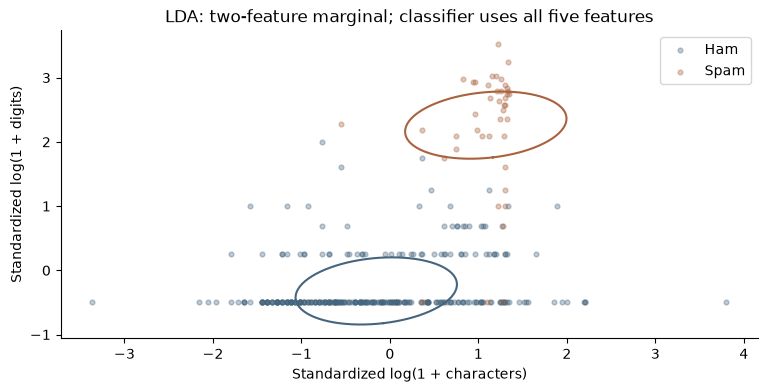

In [42]:
lda_result = lab.lda({})
fig, ax = plt.subplots()
for label, color in [(0, HAM), (1, SPAM)]:
    points = np.asarray([[p["x"], p["y"]] for p in lda_result["points"] if p["label"] == label])
    ax.scatter(points[:, 0], points[:, 1], s=12, alpha=.35, color=color, label="Ham" if label == 0 else "Spam")
    ellipse = np.asarray(lda_result["ellipses"][label])
    ax.plot(ellipse[:, 0], ellipse[:, 1], color=color)
ax.set(xlabel="Standardized log(1 + characters)", ylabel="Standardized log(1 + digits)", title="LDA: two-feature marginal; classifier uses all five features")
ax.legend()
plt.show()

## 13. GAM: Learning Curved Feature Effects

### One smooth effect for each measurement

A numerical feature may have a curved effect. We build an additive binomial model with separate spline bases for the five measurements.

- Numerical LR uses a constant slope for each log-transformed measurement. GAM allows that slope to change through a smooth curve.
- Each feature has its own spline basis, fitted by `SplineTransformer` followed by `LogisticRegression`. Effects add together; there are no feature interactions.

### Formula and notation

$$\log\frac{p}{1-p}=b+\sum_{j=1}^{5}f_j(x_j),\qquad f_j(x)=\sum_m\beta_{jm}B_{m}(x)$$

- $f_j$: smooth effect of feature j
- $B_m$: cubic spline basis function
- $\beta_{jm}$: fitted coefficients

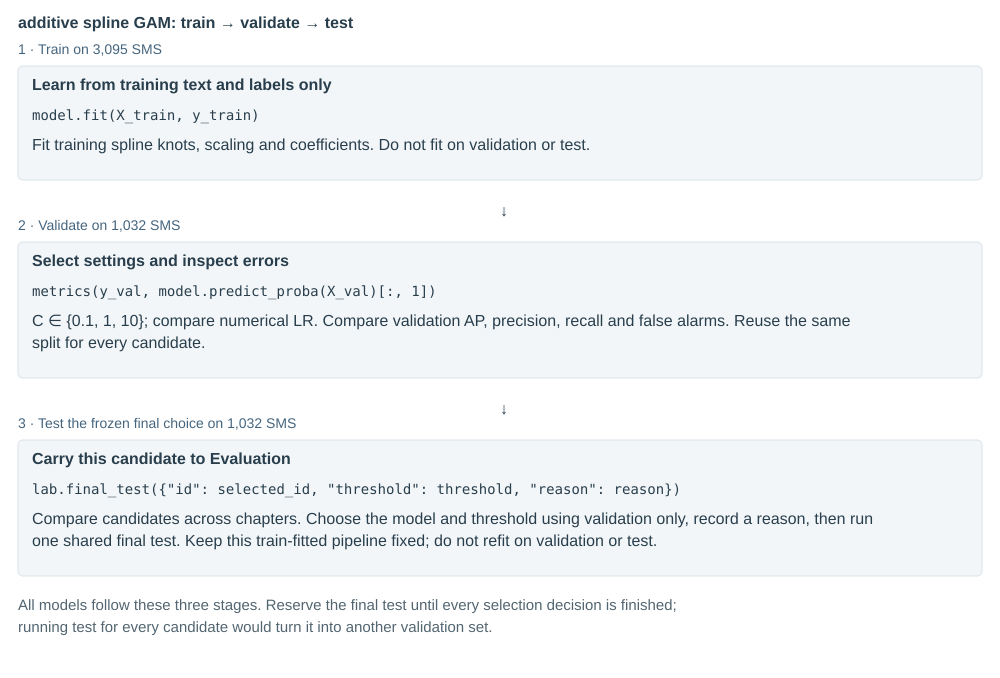

In [43]:
draw_flow(curriculum["chapters"][12]["workflow"], initial)

### Add five fitted curve effects for a real SMS

This worked GAM uses C=1 fitted on all training SMS. Start at the training-median counts: `[61, 11, 0, 0, 0]`. Its model score is -5.1175.

Now predict the same validation SMS: `You have won ?1,000 cash or a ?2,000 prize! To claim, call09050000327. T&C: RSTM, SW7 3SS. 150ppm`. Move one feature from its training median to this SMS count while holding the other four fixed. Read the score change from that fitted curve; sum all five changes.

Reference score + feature changes = -5.1175 + (1.6762 + -0.3672 + 0.0000 + 8.6523 + 1.2206) = 6.0644. Sigmoid(score) gives 99.77% spam. The sum reconstructs the full model because there are no interactions. Compare C on validation before using a GAM candidate in the final test.

| Feature | Training median count | SMS count | Fitted curve effect relative to median |
| --- | --- | --- | --- |
| Characters | 61 | 97 | +1.6762 |
| Tokens | 11 | 14 | -0.3672 |
| Links | 0 | 0 | +0.0000 |
| Digits | 0 | 24 | +8.6523 |
| Exclamation marks | 0 | 1 | +1.2206 |

### What the spline implementation assumes

This sklearn implementation fits an additive binomial model. Its L2 coefficient penalty differs from the derivative-based roughness penalty used by dedicated GAM packages. Compare against numerical LR on the same measurements.

### Inspect the fitted feature curves

Find a curve that is clearly not straight. What would one constant weight miss?

### Python: spline features and an additive classifier

Run the example, change one input or choice, then explain the output.

In [44]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, SplineTransformer, StandardScaler
from experiment import numerical_features

candidates = []
for kind, C in [(kind, C) for kind in ["logistic", "gam"] for C in [.1, 1, 10]]:
    steps = [("features", FunctionTransformer(numerical_features)), ("log", FunctionTransformer(np.log1p))]
    if kind == "gam":
        steps.append(("splines", SplineTransformer(n_knots=4, degree=3, include_bias=False)))
    steps += [("scale", StandardScaler()), ("classifier", LogisticRegression(C=C, solver="liblinear", max_iter=1000, random_state=3612))]
    model = Pipeline(steps)
    model.fit(X_train, y_train)
    print(kind, "validation AP:", metrics(y_val, model.predict_proba(X_val)[:, 1])["average_precision"])
    val = metrics(y_val, model.predict_proba(X_val)[:, 1])
    candidates.append({"model": model, "setting": {"kind": kind, "C": C}, "validation": val})
    print("Training AP:", metrics(y_train, model.predict_proba(X_train)[:, 1])["average_precision"])

# 2. Select using validation AP; the fitted pipeline stays unchanged.
best = max(candidates, key=lambda row: row["validation"]["average_precision"])
model = best["model"]
print("Selected setting:", best["setting"])
print("Selected validation metrics:", best["validation"])
# 3. TEST STAGE: carry this candidate to Evaluation; choose a threshold on validation.
# Freeze one overall model and threshold there, then evaluate test exactly once.
# Do not evaluate each hyperparameter on test or retune after seeing its result.

logistic validation AP: 0.9458242907931079


Training AP: 0.9470979440212743


logistic validation AP: 0.9453045987771983


Training AP: 0.9474286734955022


logistic validation AP: 0.9444786279413668


...

Training AP: 0.9536332212947465


gam validation AP: 0.9566391488308166


Training AP: 0.9553747779936287


gam validation AP: 0.9573076854909758


Training AP: 0.956012563776201
Selected setting: {'kind': 'gam', 'C': 10}
Selected validation metrics: {'accuracy': 0.9815891472868217, 'precision': 0.9824561403508771, 'recall': 0.8682170542635659, 'f1': 0.9218106995884774, 'confusion': [[901, 2], [17, 112]], 'false_positive_rate': 0.0022148394241417496, 'log_loss': 0.06735514669712418, 'average_precision': 0.9573076854909758, 'roc_auc': 0.9836462437868604}


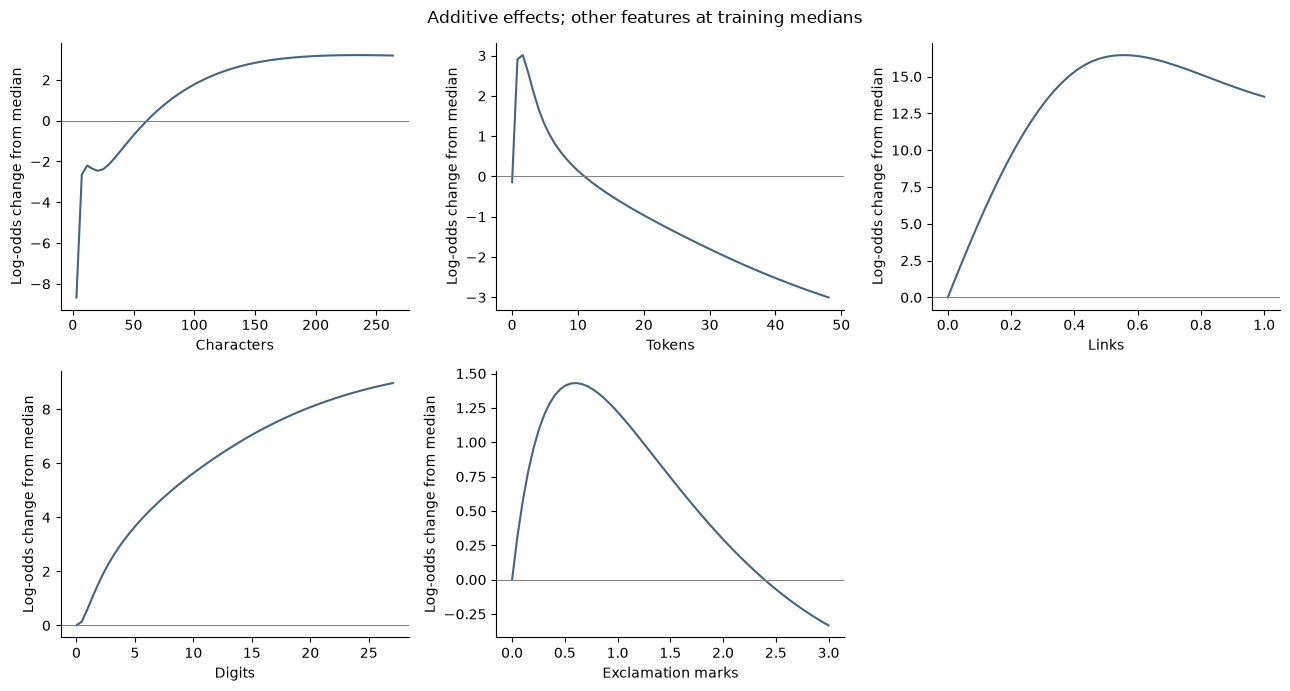

In [45]:
gam_result = lab.gam({"C": 1})
fig, axes = plt.subplots(2, 3, figsize=(13, 7))
for item, ax in zip(gam_result["curves"], axes.flat):
    ax.plot(item["x"], item["effect"], color=HAM)
    ax.axhline(0, color="grey", linewidth=.7)
    ax.set(xlabel=item["name"], ylabel="Log-odds change from median")
axes.flat[-1].axis("off")
fig.suptitle("Additive effects; other features at training medians")
plt.tight_layout()
plt.show()

## 14. Evaluation: Compare Models and Inspect Errors

### Choose with validation, report the final test

Choose a model for its validation performance and the mistakes it makes.

- Compare one choice at a time on the same validation messages. For numerical LDA/GAM comparisons, filter to numerical runs.
- Precision measures how many flagged messages are spam; recall measures how much spam is caught. AP summarizes precision–recall ranking over thresholds.

### Formula and notation

$$\mathrm{Precision}=\frac{TP}{TP+FP},\qquad\mathrm{Recall}=\frac{TP}{TP+FN}$$

- $FP$: normal message blocked
- $FN$: spam missed

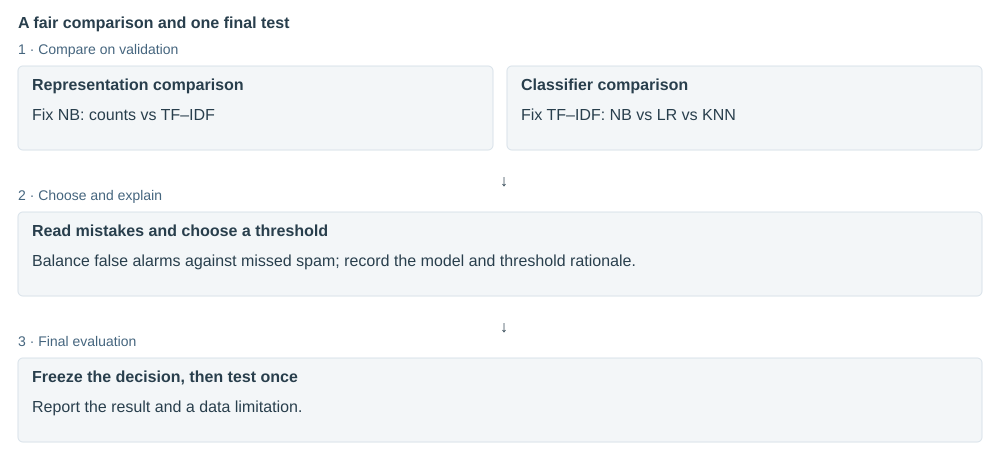

In [46]:
draw_flow(curriculum["chapters"][13]["flow"], initial)

### The cost of a false alarm and a missed spam message

A false positive blocks a normal message. A false negative lets spam through. Read examples of both: which words or preprocessing choices might explain the mistake?

All methods here lose some information about language. Historical English SMS results do not establish performance on modern email, Chinese messages or another population.

### Compare candidates, then inspect their mistakes

Compare the representations, then the classifiers. Read one false positive and one false negative, justify a model and threshold, and report a data limitation.

### Python: controlled comparisons and error metrics

Run the example, change one input or choice, then explain the output.

In [47]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix
from experiment import tokens

# 1. Keep NB fixed; compare representations.
for Vectorizer in [CountVectorizer, TfidfVectorizer]:
    model = Pipeline([
        ("vectorizer", Vectorizer(tokenizer=tokens, token_pattern=None, lowercase=False, min_df=2, max_features=2500)),
        ("classifier", MultinomialNB())
    ])
    model.fit(X_train, y_train)
    result = metrics(y_val, model.predict_proba(X_val)[:, 1])
    print("Representation:", Vectorizer.__name__, "NB AP:", round(result["average_precision"], 3))

# 2. Keep TF–IDF fixed; compare classifiers on the same validation messages.
for classifier in [MultinomialNB(), LogisticRegression(solver="liblinear", max_iter=1000, random_state=3612), KNeighborsClassifier(n_neighbors=5, metric="cosine", algorithm="brute")]:
    model = Pipeline([
        ("vectorizer", TfidfVectorizer(tokenizer=tokens, token_pattern=None, lowercase=False, min_df=2, max_features=2500)),
        ("classifier", classifier)
    ])
    model.fit(X_train, y_train)
    result = metrics(y_val, model.predict_proba(X_val)[:, 1])
    print("Classifier:", classifier.__class__.__name__, "AP:", round(result["average_precision"], 3), "precision:", round(result["precision"], 3), "recall:", round(result["recall"], 3))

# Inspect the last classifier’s actual validation decisions.
predicted = model.predict(X_val)
print(classification_report(y_val, predicted, target_names=["ham", "spam"], zero_division=0))
print("Validation confusion matrix:\n", confusion_matrix(y_val, predicted, labels=[0, 1]))

Representation: CountVectorizer NB AP: 0.952


Representation: TfidfVectorizer NB AP: 0.943


Classifier: MultinomialNB AP: 0.943 precision: 1.0 recall: 0.682


Classifier: LogisticRegression AP: 0.958 precision: 1.0 recall: 0.729


Classifier: KNeighborsClassifier AP: 0.899 precision: 0.989 recall: 0.682
              precision    recall  f1-score   support

         ham       0.96      1.00      0.98       903
        spam       0.99      0.68      0.81       129

    accuracy                           0.96      1032
   macro avg       0.97      0.84      0.89      1032
weighted avg       0.96      0.96      0.96      1032

Validation confusion matrix:
 [[902   1]
 [ 41  88]]


### Select a candidate and inspect validation errors

The lab helper keeps candidates for the error plots and final test cell, using the same pipelines shown above. The same setting grids from the model chapters are registered below, including numerical models and CV-selected LR. Use one shared validation comparison and do not evaluate every candidate on test. Choose using validation evidence, then write a reason before testing.

run8 nb count validation AP: 0.951
run9 nb count validation AP: 0.952
run10 nb count validation AP: 0.919
run11 nb tfidf validation AP: 0.96
run12 nb tfidf validation AP: 0.943
run13 nb tfidf validation AP: 0.876
run14 logistic tfidf validation AP: 0.67
run15 logistic tfidf validation AP: 0.935
run16 logistic tfidf validation AP: 0.948
run17 logistic tfidf validation AP: 0.958
run18 logistic tfidf validation AP: 0.962
run19 knn tfidf validation AP: 0.87
run20 knn tfidf validation AP: 0.899
run21 knn tfidf validation AP: 0.934
run22 logistic numeric validation AP: 0.946
run23 logistic numeric validation AP: 0.945
run24 logistic numeric validation AP: 0.944
run25 lda numeric validation AP: 0.947
run26 lda numeric validation AP: 0.948
run27 lda numeric validation AP: 0.94
run28 gam numeric validation AP: 0.954
run29 gam numeric validation AP: 0.957
run30 gam numeric validation AP: 0.957
run31 logistic tfidf validation AP: 0.962
Selected validation metrics: {'accuracy': 0.9825581395348837,

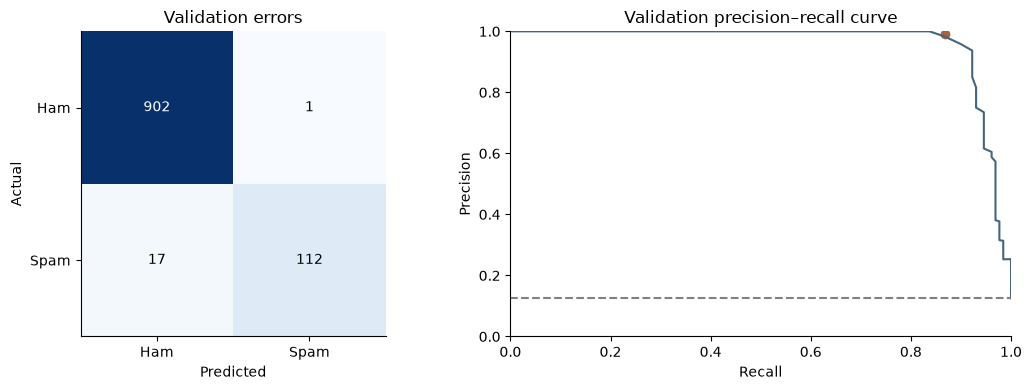

In [48]:
# These finite setting grids match the complete training/validation experiments.
configs = ([{"kind": "nb", "representation": r, "alpha": a} for r in ["count", "tfidf"] for a in [.1, 1, 5]]
           + [{"kind": "logistic", "representation": "tfidf", "C": C} for C in [.001, .01, .1, 1, 10]]
           + [{"kind": "knn", "representation": "tfidf", "k": k} for k in [3, 5, 15]]
           + [{"kind": "logistic", "representation": "numeric", "C": C} for C in [.1, 1, 10]]
           + [{"kind": "lda", "representation": "numeric", "shrinkage": a} for a in ["auto", .1, .5]]
           + [{"kind": "gam", "representation": "numeric", "C": C} for C in [.1, 1, 10]]
           + [{"kind": "logistic", "representation": "tfidf", "C": search.best_params_["classifier__C"]}])
core_candidates = [lab.fit(config) for config in configs]
for row in core_candidates:
    print(row["id"], row["kind"], row["representation"], "validation AP:", round(row["validation"]["average_precision"], 3))
selected_id = max(core_candidates, key=lambda row: row["validation"]["average_precision"])["id"]
threshold = .5  # Change only using validation evidence.
validation_result = lab.evaluate({"id": selected_id, "threshold": threshold})
print("Selected validation metrics:", validation_result["metrics"])
for item in validation_result["errors"][:8]:
    print("True", item["label"], "predicted", item["prediction"], "p", round(item["probability"], 3), "|", item["text"])
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
cm = np.asarray(validation_result["metrics"]["confusion"])
axes[0].imshow(cm, cmap="Blues")
for (r, c), value in np.ndenumerate(cm):
    axes[0].text(c, r, str(value), ha="center", va="center", color="white" if value > cm.max() / 2 else "black")
axes[0].set(xticks=[0, 1], yticks=[0, 1], xticklabels=["Ham", "Spam"], yticklabels=["Ham", "Spam"], xlabel="Predicted", ylabel="Actual", title="Validation errors")
pr = np.asarray(validation_result["pr"])
axes[1].plot(pr[:, 0], pr[:, 1], color=HAM)
axes[1].axhline(validation_result["prevalence"], ls="--", color="grey")
axes[1].scatter(validation_result["metrics"]["recall"], validation_result["metrics"]["precision"], color=SPAM)
axes[1].set(xlabel="Recall", ylabel="Precision", xlim=(0, 1), ylim=(0, 1), title="Validation precision–recall curve")
plt.tight_layout()
plt.show()

### Freeze the decision and evaluate the test set

Explain your representation, classifier and threshold using validation evidence. Include the error tradeoff and a data limitation. This cell runs only when the rationale is nonempty. After testing, the lab freezes the decision. Restarting Python does not make an inspected test set unseen again.

In [49]:
reason = ''  # Write your model and threshold rationale before testing.
if reason.strip():
    final_result = lab.final_test({'id': selected_id, 'threshold': threshold, 'reason': reason})
    print(json.dumps(final_result, indent=2))
else:
    print('Record a rationale above, then run the final test once.')

Record a rationale above, then run the final test once.


## Your experiment record

Report the raw-file audit, one preprocessing choice, the representation comparison, the classifier comparison, training/validation selection for every model, a false positive, a false negative and your final rationale/test result.

In [50]:
record = {'dataset': 'Original UCI SMS Spam Collection', 'seed': 3612, 'splits': initial['counts'],
          'runs': [{k: v for k, v in item['row'].items() if k != 'thresholds'} for item in lab.runs.values()],
          'final': lab.final}
print('Recorded candidates:', len(record['runs']))
Path('tutorial05-results.json').write_text(json.dumps(record, indent=2))

Recorded candidates: 31


55048

## Appendix: supporting scientific functions

The lesson examples above show the NLTK and sklearn calls directly. These functions are copied from `experiment.py` for readers who want to inspect or modify data loading, measurements and experiment bookkeeping. They are not prerequisites for following the lesson.

In [51]:
import csv
import re
from nltk.tokenize import TreebankWordTokenizer
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (average_precision_score, confusion_matrix, log_loss,
                             precision_recall_curve, roc_auc_score, roc_curve)
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, SplineTransformer, StandardScaler
from experiment import SEED, FEATURES

### `tokens`

In [52]:
def tokens(text):
    """NLTK splits punctuation; retain alphanumeric tokens for this baseline."""
    return [word for word in TreebankWordTokenizer().tokenize(text.lower())
            if word.isalnum()]

### `text_vectorizer`

In [53]:
def text_vectorizer(representation='count', **options):
    """Use the SAME NLTK preprocessing in toy examples and real classifiers."""
    vectorizer = CountVectorizer if representation == 'count' else TfidfVectorizer
    return vectorizer(tokenizer=tokens, token_pattern=None, lowercase=False, **options)

### `numerical_features`

In [54]:
def numerical_features(messages):
    """Hand-designed observations; no labels or fitted statistics are used."""
    return np.asarray([[len(s), len(tokens(s)),
                        len(re.findall(r'https?://|www\.', s, flags=re.I)),
                        sum(c.isdigit() for c in s), s.count('!')]
                       for s in messages], dtype=float)

### `load_data`

In [55]:
def load_data(path):
    """Deduplicate message identities BEFORE splitting; reject label conflicts."""
    with open(path, encoding='utf-8-sig', newline='') as handle:
        rows = list(csv.DictReader(handle, fieldnames=['Category', 'Message'],
                                   delimiter='\t', quoting=csv.QUOTE_NONE))
    unique = {}
    excluded = 0
    for row in rows:
        text, category = row['Message'], row['Category']
        if category not in ('ham', 'spam'):
            raise ValueError('Expected ham/spam Category.')
        if not text.strip() or text.strip() == '#ERROR!':
            excluded += 1
            continue
        # Identical after whitespace/case normalization must not cross splits.
        identity = ' '.join(text.lower().split())
        label = int(category == 'spam')
        if identity in unique and unique[identity][1] != label:
            raise ValueError('Conflicting labels for the same message.')
        unique.setdefault(identity, (text, label))
    messages = np.asarray([r[0] for r in unique.values()])
    labels = np.asarray([r[1] for r in unique.values()], dtype=int)
    train_val, test = train_test_split(np.arange(len(labels)), test_size=.2,
                                      stratify=labels, random_state=SEED)
    train, validation = train_test_split(train_val, test_size=.25,
                                       stratify=labels[train_val], random_state=SEED)
    return messages, labels, {'train': train, 'validation': validation, 'test': test}, {'raw': len(rows), 'excluded': excluded}

### `decision_metrics`

In [56]:
def decision_metrics(y, probability, threshold=.5):
    """Threshold-dependent decisions, computed once in the scientific layer."""
    p = np.asarray(probability, dtype=float)
    prediction = (p >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y, prediction, labels=[0, 1]).ravel()
    precision = tp / (tp + fp) if tp + fp else 0.
    recall = tp / (tp + fn) if tp + fn else 0.
    return {'accuracy': float((prediction == y).mean()), 'precision': float(precision),
            'recall': float(recall), 'f1': float(2 * precision * recall / (precision + recall))
            if precision + recall else 0., 'confusion': [[int(tn), int(fp)], [int(fn), int(tp)]],
            'false_positive_rate': float(fp / (tn + fp)) if tn + fp else 0.}

### `metrics`

In [57]:
def metrics(y, probability, threshold=.5):
    """Positive class is spam. Undefined precision is reported as zero."""
    p = np.asarray(probability, dtype=float)
    return {**decision_metrics(y, p, threshold),
            'log_loss': float(log_loss(y, np.clip(p, 1e-12, 1 - 1e-12), labels=[0, 1])),
            'average_precision': float(average_precision_score(y, p)),
            'roc_auc': float(roc_auc_score(y, p))}

### `build_model`

In [58]:
def build_model(kind='logistic', representation='count', C=1., k=5, alpha=1., shrinkage='auto'):
    """Keep every learned transformation inside the pipeline."""
    if kind not in ('logistic', 'nb', 'knn', 'lda', 'gam'):
        raise ValueError('Unknown model.')
    if representation not in ('count', 'tfidf', 'numeric'):
        raise ValueError('Unknown representation.')
    if kind == 'nb' and (representation == 'numeric' or alpha <= 0):
        raise ValueError('Naive Bayes needs nonnegative text features and alpha > 0.')
    if representation == 'numeric' or kind in ('lda', 'gam'):
        steps = [('features', FunctionTransformer(numerical_features)),
                 ('log', FunctionTransformer(np.log1p))]
        if kind == 'gam':
            # Separate spline bases for each input; no feature interactions.
            steps += [('splines', SplineTransformer(n_knots=4, degree=3,
                                                    include_bias=False))]
        steps += [('scale', StandardScaler())]
    else:
        steps = [('vectorizer', text_vectorizer(representation, min_df=2,
                                               max_features=2500))]
    if kind == 'lda':
        classifier = LinearDiscriminantAnalysis(solver='lsqr', shrinkage=shrinkage)
    elif kind == 'knn':
        classifier = KNeighborsClassifier(n_neighbors=int(k), algorithm='brute',
                                           metric='euclidean' if representation == 'numeric' else 'cosine')
    elif kind == 'nb':
        classifier = MultinomialNB(alpha=float(alpha))
    else:
        classifier = LogisticRegression(C=float(C), solver='liblinear', max_iter=1000,
                                         random_state=SEED)
    return Pipeline(steps + [('classifier', classifier)])

### `explain_model`

In [59]:
def explain_model(model, text, X_train, y_train):
    """Explain the fitted pipeline on one message without refitting any step."""
    vector = model[:-1].transform([text])
    classifier = model.named_steps['classifier']
    prediction = int(model.predict([text])[0])
    if isinstance(classifier, MultinomialNB):
        values = vector.toarray()[0]
        names = model.named_steps['vectorizer'].get_feature_names_out()
        log_ratio = classifier.feature_log_prob_[1] - classifier.feature_log_prob_[0]
        contributions = values * log_ratio
        active = np.flatnonzero(values)
        order = active[np.argsort(-np.abs(contributions[active]))]
        bias = float(classifier.class_log_prior_[1] - classifier.class_log_prior_[0])
        return {'text': text, 'bias': bias, 'score': float(bias + contributions.sum()),
                'probability': float(model.predict_proba([text])[0, 1]), 'prediction': prediction,
                'priors': np.exp(classifier.class_log_prior_).tolist(),
                'evidence': [{'word': str(names[j]), 'value': float(values[j]),
                              'ham': float(np.exp(classifier.feature_log_prob_[0, j])),
                              'spam': float(np.exp(classifier.feature_log_prob_[1, j])),
                              'contribution': float(contributions[j])} for j in order]}
    if not hasattr(classifier, 'coef_'):
        distances, indices = classifier.kneighbors(vector)
        return {'text': text, 'neighbors': [{'text': str(X_train[i]), 'label': int(y_train[i]),
                               'distance': float(d)} for d, i in zip(distances[0], indices[0])],
                'probability': float(model.predict_proba([text])[0, 1]), 'prediction': prediction,
                'metric': classifier.metric,
                'zero_vector': bool('vectorizer' in model.named_steps and vector.nnz == 0)}
    values = vector.toarray()[0] if hasattr(vector, 'toarray') else vector[0]
    contributions = values * classifier.coef_[0]
    if 'vectorizer' in model.named_steps:
        names = model.named_steps['vectorizer'].get_feature_names_out()
    elif 'splines' in model.named_steps:
        n = len(values) // len(FEATURES)
        contributions = contributions.reshape(len(FEATURES), n).sum(axis=1)
        names = FEATURES
    else:
        names = FEATURES
    active = np.flatnonzero(contributions)
    order = active[np.argsort(-np.abs(contributions[active]))]
    bias = float(classifier.intercept_[0])
    return {'contributions': [dict(name=str(names[i]), value=float(contributions[i]),
                            **({'feature': float(values[i]), 'weight': float(classifier.coef_[0, i])}
                               if isinstance(classifier, LogisticRegression) and 'splines' not in model.named_steps else {}))
                        for i in order],
            'bias': bias, 'score': float(bias + contributions.sum()),
            'probability': float(model.predict_proba([text])[0, 1]), 'prediction': prediction,
            'text': text, 'numeric': numerical_features([text])[0].tolist()}

### `cross_validate`

In [60]:
def cross_validate(messages, labels, representation='count', values=(.01, .1, 1., 10.)):
    """Fit vocabulary, IDF and model afresh inside EACH training fold."""
    folds = list(StratifiedKFold(5, shuffle=True, random_state=SEED).split(messages, labels))
    rows = []
    for C in values:
        scores, training, vocabulary_sizes = [], [], []
        for train, heldout in folds:
            model = build_model(C=C, representation=representation)
            model.fit(messages[train], labels[train])
            scores.append(average_precision_score(labels[heldout], model.predict_proba(messages[heldout])[:, 1]))
            training.append(average_precision_score(labels[train], model.predict_proba(messages[train])[:, 1]))
            vocabulary_sizes.append(len(model.named_steps['vectorizer'].vocabulary_))
        rows.append({'C': C, 'folds': list(map(float, scores)), 'train': float(np.mean(training)),
                     'mean': float(np.mean(scores)), 'std': float(np.std(scores, ddof=1)),
                     'vocabulary_sizes': vocabulary_sizes})
    return rows